# TestCompare

This notebook compares selected schemes on the same bundle-reconstructed environment. By default it compares **Local MPC + LSTM Forecast** and **ADMM MPC + LSTM Forecast**, and it can optionally add one DRL scheme.


In [1]:
from copy import deepcopy
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "configs").exists():
    repo_root = repo_root.parent
if not (repo_root / "configs").exists():
    raise RuntimeError("Could not locate the project root from the notebook working directory.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from configs import compose_experiment_config
from scripts.utils import grid_notebook_workflow as grid_nb
from scripts.utils.admm_mpc_notebook_helpers import collect_admm_mpc_rollout
from scripts.utils.experiment_notebook_utils import resolve_madrl_model_root
from scripts.utils.grid_notebook_workflow import collect_madrl_rollout, load_training_run_bundle
from scripts.utils.madrl_shared_data import ensure_madrl_shared_data, load_madrl_shared_data_manifest
from scripts.utils.project_paths import project_root as resolve_project_root


In [2]:
PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "data"

TEST_START_DATE = "2020-06-01"
TEST_END_DATE = "2020-06-02"
PREDICTION_MODE = "normal"
SHOW_PROGRESS = True

SELECTED_SCHEMES = ["admm_mpc", "drl_no_safety", "drl_safety_penalty", "drl_safety_projection"]
DRL_MODEL_ROOT_OVERRIDES = {}
REFERENCE_SCHEME = "drl_safety_projection"

CHECKPOINT_ROOT = None

EVAL_W_VOLTAGE_PEN = 10.0
EVAL_W_LINE_PEN = 10.0
EVAL_W_TRAFO_PEN = 10.0

# Add "local_mpc" to SELECTED_SCHEMES if you want to include it in the comparison.
# If PREDICTION_MODE="normal" fails with an LSTM artifact metadata mismatch, refresh the forecast artifacts first.
SCHEME_OPTIONS = (
    "local_mpc",
    "admm_mpc",
    "drl_no_safety",
    "drl_safety_penalty",
    "drl_safety_projection",
)
SCHEME_SPECS = {
    "local_mpc": {
        "is_drl": False,
        "controller_label": "Local MPC + LSTM Forecast",
    },
    "admm_mpc": {
        "is_drl": False,
        "controller_label": "ADMM MPC + LSTM Forecast",
    },
    "drl_no_safety": {
        "is_drl": True,
        "algorithm": "MATD3",
        "experiment_name": "train_base",
        "controller_label": "MADRL + No Safety",
    },
    "drl_safety_penalty": {
        "is_drl": True,
        "algorithm": "MATD3",
        "experiment_name": "train_base_safe",
        "controller_label": "MADRL + Safety Penalty",
    },
    "drl_safety_projection": {
        "is_drl": True,
        "algorithm": "MATD3_SAFE_POC",
        "experiment_name": "train_projection_safe",
        "controller_label": "MADRL + Safety Projection",
    },
}


In [3]:
selected_schemes = [str(value).strip().lower() for value in SELECTED_SCHEMES]
if not selected_schemes:
    raise ValueError("SELECTED_SCHEMES must contain at least one scheme.")
unknown_schemes = [scheme for scheme in selected_schemes if scheme not in SCHEME_OPTIONS]
if unknown_schemes:
    raise ValueError(f"Unknown scheme(s) requested: {unknown_schemes}. Supported values: {SCHEME_OPTIONS}.")
if len(selected_schemes) != len(dict.fromkeys(selected_schemes)):
    raise ValueError(f"SELECTED_SCHEMES must not contain duplicates: {selected_schemes}.")

selected_drl_schemes = [scheme for scheme in selected_schemes if SCHEME_SPECS[scheme]["is_drl"]]
drl_scheme_options = tuple(scheme for scheme, spec in SCHEME_SPECS.items() if spec["is_drl"])
if REFERENCE_SCHEME not in drl_scheme_options:
    raise ValueError(
        f"REFERENCE_SCHEME must be one of {drl_scheme_options}, got {REFERENCE_SCHEME!r}."
    )

resolved_drl_model_roots = {}
selected_drl_bundles = {}
if selected_drl_schemes:
    for scheme in selected_drl_schemes:
        spec = SCHEME_SPECS[scheme]
        resolved_drl_model_roots[scheme] = resolve_madrl_model_root(
            algorithm=spec["algorithm"],
            prediction_mode=PREDICTION_MODE,
            experiment_name=spec["experiment_name"],
            model_root=DRL_MODEL_ROOT_OVERRIDES.get(scheme, None),
            root=PROJECT_ROOT,
            checkpoint_root=CHECKPOINT_ROOT,
        )
    if len(selected_drl_schemes) >= 2:
        selected_drl_bundles = grid_nb.validate_compare_model_bundles(
            {scheme: resolved_drl_model_roots[scheme] for scheme in selected_drl_schemes},
            expected_count=len(selected_drl_schemes),
        )
    else:
        only_scheme = selected_drl_schemes[0]
        selected_drl_bundles[only_scheme] = load_training_run_bundle(resolved_drl_model_roots[only_scheme])
    reference_scheme_key = selected_drl_schemes[0]
    reference_bundle = selected_drl_bundles[reference_scheme_key]
else:
    reference_spec = SCHEME_SPECS[REFERENCE_SCHEME]
    resolved_drl_model_roots[REFERENCE_SCHEME] = resolve_madrl_model_root(
        algorithm=reference_spec["algorithm"],
        prediction_mode=PREDICTION_MODE,
        experiment_name=reference_spec["experiment_name"],
        model_root=DRL_MODEL_ROOT_OVERRIDES.get(REFERENCE_SCHEME, None),
        root=PROJECT_ROOT,
        checkpoint_root=CHECKPOINT_ROOT,
    )
    reference_scheme_key = REFERENCE_SCHEME
    reference_bundle = load_training_run_bundle(resolved_drl_model_roots[REFERENCE_SCHEME])

reference_experiment = reference_bundle["experiment_controls"]
reference_data = reference_bundle["data_controls"]
reference_battery = reference_bundle["battery_controls"]
reference_train = reference_bundle["train_controls"]

forecast_controls = dict(reference_experiment.get("forecast_controls") or {})
if forecast_controls:
    forecast_controls["auto_train_missing"] = False
resolved_prediction_mode = PREDICTION_MODE or reference_data["prediction_mode"]

base_cfg = compose_experiment_config(
    profile=reference_train.get("profile", "base"),
    algorithm="MATD3",
    model_family=reference_train.get("model_family", "mlp"),
    data_dir=DATA_DIR,
    device=reference_experiment.get("device_request"),
    runtime_mode=reference_experiment.get("runtime_mode", "performance"),
    seed=int(reference_experiment.get("seed", 0)),
    require_cuda=reference_experiment.get("require_cuda"),
)
grid_nb.apply_notebook_experiment_settings(
    base_cfg,
    prediction_mode=resolved_prediction_mode,
    test_start_date=TEST_START_DATE or reference_data.get("test_start_date"),
    test_end_date=TEST_END_DATE or reference_data.get("test_end_date"),
    agent_profiles=reference_data["agent_profiles"],
    agent_bus_ids=reference_data.get("agent_bus_ids"),
    load_scale=reference_data.get("load_scale"),
    pv_scale=reference_data.get("pv_scale"),
    battery_controls=reference_battery,
    forecast_controls=forecast_controls,
    future_horizon=reference_data.get("future_horizon"),
    train_year=reference_data.get("train_year"),
    test_year=reference_data.get("test_year"),
)
base_cfg.reward.w_voltage_pen = EVAL_W_VOLTAGE_PEN
base_cfg.reward.w_line_pen = EVAL_W_LINE_PEN
base_cfg.reward.w_trafo_pen = EVAL_W_TRAFO_PEN
base_cfg.env.episode_limit = int(round(24.0 / base_cfg.env.dt))
if abs(float(base_cfg.env.dt) * int(base_cfg.env.episode_limit) - 24.0) > 1e-9:
    raise ValueError("TestCompare notebook expects one full day per episode.")
base_cfg.runtime.shared_data_dir = None
base_cfg.runtime.shared_data_signature = None
base_cfg.runtime.forecast_ready = None

requested_window_start_date = str(base_cfg.data.test_start_date)
requested_window_end_date = str(base_cfg.data.test_end_date)

def _resolve_window_bounds_for_series(timestamp_series, *, start_date: str, end_date: str):
    timestamps = pd.to_datetime(timestamp_series)
    sample_timestamp = timestamps.iloc[0] if hasattr(timestamps, "iloc") else timestamps[0]
    window_start = pd.Timestamp(start_date)
    window_end = pd.Timestamp(end_date) + pd.Timedelta(days=1)
    if getattr(sample_timestamp, "tzinfo", None) is not None:
        window_start = window_start.tz_localize(sample_timestamp.tzinfo)
        window_end = window_end.tz_localize(sample_timestamp.tzinfo)
    return window_start, window_end

def _select_overlapping_shared_test_episode_indices(shared_test_manifest, *, start_date: str, end_date: str):
    episodes = list(shared_test_manifest.get("episodes") or [])
    if not episodes:
        raise ValueError("Shared-data test manifest does not contain episode metadata.")
    requested_start = pd.Timestamp(start_date).date()
    requested_end = pd.Timestamp(end_date).date()
    selected = []
    for entry in episodes:
        first_local_date = pd.Timestamp(str(entry["first_local_date"])).date()
        last_local_date = pd.Timestamp(str(entry["last_local_date"])).date()
        if first_local_date <= requested_end and last_local_date >= requested_start:
            selected.append(int(entry["episode_idx"]))
    if not selected:
        raise ValueError(
            "No shared-data episodes overlap the requested local compare window: "
            f"start_date={start_date!r}, end_date={end_date!r}."
        )
    return selected

def _slice_rollout_to_requested_local_window(rollout, *, start_date: str, end_date: str):
    if rollout.step_df.empty or "timestamp" not in rollout.step_df.columns:
        return rollout
    window_start, window_end = _resolve_window_bounds_for_series(
        rollout.step_df["timestamp"],
        start_date=start_date,
        end_date=end_date,
    )

    def _filter_timestamp_frame(frame):
        if frame.empty or "timestamp" not in frame.columns:
            return frame.copy()
        timestamps = pd.to_datetime(frame["timestamp"])
        mask = (timestamps >= window_start) & (timestamps < window_end)
        return frame.loc[mask].copy().reset_index(drop=True)

    step_df = _filter_timestamp_frame(rollout.step_df)
    agent_df = _filter_timestamp_frame(rollout.agent_df)
    grid_df = _filter_timestamp_frame(rollout.grid_df)
    if step_df.empty:
        raise ValueError(
            f"Rollout {rollout.meta.get('controller', 'unknown')!r} has no samples inside the requested local window "
            f"[{window_start}, {window_end})."
        )
    summary_columns = [column for column in ["purchase_cost", "export_subsidy", "objective_total"] if column in agent_df.columns]
    if agent_df.empty or not {"controller", "agent_profile"}.issubset(agent_df.columns) or not summary_columns:
        summary = rollout.summary.copy()
    else:
        summary = agent_df.groupby(["controller", "agent_profile"], as_index=False)[summary_columns].sum()
    meta = dict(rollout.meta)
    meta["trimmed_to_requested_local_window"] = True
    meta["requested_test_start_date"] = start_date
    meta["requested_test_end_date"] = end_date
    if "episode_idx" in step_df.columns:
        meta["selected_episode_indices"] = [int(index) for index in pd.unique(step_df["episode_idx"])]
    return grid_nb.RolloutResult(
        step_df=step_df,
        agent_df=agent_df,
        grid_df=grid_df,
        summary=summary,
        meta=meta,
    )

selection_rows = []
for scheme in selected_schemes:
    spec = SCHEME_SPECS[scheme]
    selection_rows.append(
        {
            "scheme_key": scheme,
            "controller_label": spec["controller_label"],
            "algorithm": spec.get("algorithm", "n/a"),
            "experiment_name": spec.get("experiment_name", "n/a"),
            "model_root": str(resolved_drl_model_roots[scheme]) if spec["is_drl"] else "n/a",
        }
    )

display(pd.DataFrame(selection_rows))


,scheme_key,controller_label,algorithm,experiment_name,model_root
0,admm_mpc,ADMM MPC + LSTM Forecast,n/a,n/a,n/a
1,drl_no_safety,MADRL + No Safety,MATD3,train_base,D:\GithubProject\MADRL_ESS\artifacts\training\...
2,drl_safety_penalty,MADRL + Safety Penalty,MATD3,train_base_safe,D:\GithubProject\MADRL_ESS\artifacts\training\...
3,drl_safety_projection,MADRL + Safety Projection,MATD3_SAFE_POC,train_projection_safe,D:\GithubProject\MADRL_ESS\artifacts\training\...


In [4]:
collected_rollouts = {}

for scheme in selected_schemes:
    spec = SCHEME_SPECS[scheme]
    if scheme == "local_mpc":
        mpc_cfg = deepcopy(base_cfg)
        print(f"Starting {spec['controller_label']}...")
        mpc_rollout = grid_nb.collect_local_mpc_rollout(
            mpc_cfg,
            prediction_mode=resolved_prediction_mode,
            label=spec["controller_label"],
        )
        collected_rollouts[scheme] = _slice_rollout_to_requested_local_window(
            mpc_rollout,
            start_date=requested_window_start_date,
            end_date=requested_window_end_date,
        )
        print(
            "Done:",
            collected_rollouts[scheme].meta.get("controller", spec["controller_label"]),
            f"steps={len(collected_rollouts[scheme].step_df)}",
        )
        continue

    if scheme == "admm_mpc":
        admm_cfg = deepcopy(base_cfg)
        admm_cfg.runtime.shared_data_dir = None
        admm_cfg.runtime.shared_data_signature = None
        admm_cfg.runtime.forecast_ready = None
        admm_daily_steps = int(round(24.0 / float(admm_cfg.env.dt)))
        compare_episode_steps = int(base_cfg.env.episode_limit)
        requested_start = pd.Timestamp(admm_cfg.data.test_start_date)
        requested_end = pd.Timestamp(admm_cfg.data.test_end_date)
        requested_days = int((requested_end - requested_start).days) + 1
        requested_steps = requested_days * admm_daily_steps
        effective_steps = (requested_steps // compare_episode_steps) * compare_episode_steps
        if effective_steps <= 0:
            raise ValueError(
                f"ADMM MPC compare horizon collapsed to zero steps after aligning to ordinary compare episode_limit="
                f"{compare_episode_steps}; requested_days={requested_days}, requested_steps={requested_steps}."
            )
        if effective_steps % admm_daily_steps != 0:
            raise ValueError(
                f"ADMM MPC compare can only align to a whole number of days, but ordinary compare keeps "
                f"effective_steps={effective_steps} with daily_steps={admm_daily_steps}."
            )
        admm_num_days = effective_steps // admm_daily_steps
        admm_cfg.data.test_end_date = (
            requested_start + pd.Timedelta(days=admm_num_days - 1)
        ).strftime("%Y-%m-%d")
        print(
            f"ADMM MPC compare horizon aligned to ordinary compare episode_limit={compare_episode_steps}: "
            f"requested_days={requested_days}, effective_days={admm_num_days}, effective_steps={effective_steps}, "
            f"test_end_date={admm_cfg.data.test_end_date}"
        )
        print(f"Starting {spec['controller_label']}...")
        admm_rollout = collect_admm_mpc_rollout(
            admm_cfg,
            prediction_mode=resolved_prediction_mode,
            show_progress=SHOW_PROGRESS,
            label=spec["controller_label"],
        )
        collected_rollouts[scheme] = _slice_rollout_to_requested_local_window(
            admm_rollout,
            start_date=requested_window_start_date,
            end_date=requested_window_end_date,
        )
        print(
            "Done:",
            collected_rollouts[scheme].meta.get("controller", spec["controller_label"]),
            f"steps={len(collected_rollouts[scheme].step_df)}",
        )
        continue

    drl_cfg = deepcopy(base_cfg)
    shared_data_result = ensure_madrl_shared_data(drl_cfg)
    drl_cfg.runtime.shared_data_dir = str(shared_data_result.shared_data_dir)
    drl_cfg.runtime.shared_data_signature = str(shared_data_result.signature_hash)
    shared_test_manifest = load_madrl_shared_data_manifest(Path(shared_data_result.shared_data_dir) / "test")
    drl_episode_indices = _select_overlapping_shared_test_episode_indices(
        shared_test_manifest,
        start_date=requested_window_start_date,
        end_date=requested_window_end_date,
    )
    print(f"Starting {spec['controller_label']} with shared-data episodes={drl_episode_indices}...")
    drl_rollout = collect_madrl_rollout(
        drl_cfg,
        model_root=resolved_drl_model_roots[scheme],
        algorithm=spec["algorithm"],
        experiment_name=spec["experiment_name"],
        checkpoint_root=CHECKPOINT_ROOT,
        label=spec["controller_label"],
        episode_indices=drl_episode_indices,
    )
    collected_rollouts[scheme] = _slice_rollout_to_requested_local_window(
        drl_rollout,
        start_date=requested_window_start_date,
        end_date=requested_window_end_date,
    )
    print(
        "Done:",
        collected_rollouts[scheme].meta.get("controller", spec["controller_label"]),
        f"steps={len(collected_rollouts[scheme].step_df)}",
        f"episodes={collected_rollouts[scheme].meta.get('selected_episode_indices', [])}",
    )

rollouts = [collected_rollouts[scheme] for scheme in selected_schemes]
metrics_df = grid_nb.compare_rollout_metrics(*rollouts)
economic_table = grid_nb.build_compare_economic_table(metrics_df)
safety_table = grid_nb.build_compare_safety_table(metrics_df)
voltage_safety_table = safety_table.loc[
    :,
    [
        "controller",
        "voltage_violation_steps",
        "voltage_violation_bus_points",
        "voltage_step_delta_p95_pu",
        "voltage_step_delta_max_pu",
        "voltage_spread_mean_pu",
        "voltage_spread_max_pu",
    ],
].copy()
transformer_safety_table = safety_table.loc[
    :,
    [
        "controller",
        "trafo_overload_steps",
        "trafo_loading_max_pct",
        "feeder_netload_ramp_mean_abs_kw",
        "feeder_netload_ramp_max_kw",
    ],
].copy()

display(grid_nb.build_compare_warning_banner(*rollouts))
display(metrics_df)
display(economic_table)
display(voltage_safety_table)
display(transformer_safety_table)


ADMM MPC compare horizon aligned to ordinary compare episode_limit=96: requested_days=2, effective_days=2, effective_steps=192, test_end_date=2020-06-02
Starting ADMM MPC + LSTM Forecast...


d:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
d:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
d:\SOFTWARE\miniconda\envs\MADRL_ESS\Lib\site-packages\sim

ADMM MPC rollout:   0%|          | 0/192 [00:00<?, ?step/s]

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2685996
Academic license 2685996 - for non-commercial use only - registered to 20___@mail.scut.edu.cn
ADMM MPC rollout complete: processed 192/192 steps.
Done: ADMM MPC + LSTM Forecast
Starting MADRL + No Safety...
Done: MADRL + No Safety
Starting MADRL + Safety Penalty...
Done: MADRL + Safety Penalty
Starting MADRL + Safety Projection...
Done: MADRL + Safety Projection


,controller,soc_mode,purchase_cost_total,purchase_cost_total_eur,export_subsidy_total,export_subsidy_total_eur,total_cost_eur,objective_total,soc_penalty_total,voltage_penalty_total,...,returned_primary_objective_eur,high_budget_refinement_warn,formulation_tightening_required,physics_refinement_status,missing_optional_compare_fields,purchase_cost_sfh12,purchase_cost_sfh14,purchase_cost_sfh16,purchase_cost_sfh18,purchase_cost_sfh20
0,ADMM MPC + LSTM Forecast,continuous,49.149342,49.149342,288.805127,288.805127,-239.655785,-239.655785,0.000000,0.000000,...,NaN,False,False,,,11.000658,11.672866,5.998158,5.599815,14.877844
1,MADRL + No Safety,reset,43.908875,43.908875,178.496315,178.496315,-134.587440,-59.357101,39.146906,0.018562,...,NaN,False,False,,,8.049742,11.346341,10.099800,6.994899,7.418094
2,MADRL + Safety Penalty,reset,46.823091,46.823091,172.732064,172.732064,-125.908973,-43.097804,59.823231,0.012358,...,NaN,False,False,,,8.585513,11.894022,9.578273,6.963345,9.801938
3,MADRL + Safety Projection,reset,52.726470,52.726470,148.260541,148.260541,-95.534072,-95.534072,0.000000,0.000000,...,NaN,False,False,,,9.816954,14.766789,10.328503,8.367584,9.446640


,controller,purchase_cost_total_eur,export_subsidy_total_eur,total_cost_eur
0,ADMM MPC + LSTM Forecast,49.149342,288.805127,-239.655785
1,MADRL + No Safety,43.908875,178.496315,-134.587440
2,MADRL + Safety Penalty,46.823091,172.732064,-125.908973
3,MADRL + Safety Projection,52.726470,148.260541,-95.534072


,controller,voltage_violation_steps,voltage_violation_bus_points,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu
0,ADMM MPC + LSTM Forecast,0,0,0.003242,0.014970,0.013710,0.022247
1,MADRL + No Safety,20,41,0.003597,0.009690,0.016947,0.035689
2,MADRL + Safety Penalty,19,39,0.003487,0.009920,0.016675,0.037007
3,MADRL + Safety Projection,0,0,0.003192,0.009246,0.014222,0.020873


,controller,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw
0,ADMM MPC + LSTM Forecast,0,96.969009,7.565311,54.405701
1,MADRL + No Safety,26,156.291290,11.504845,50.843525
2,MADRL + Safety Penalty,27,156.775269,11.708282,53.861977
3,MADRL + Safety Projection,0,96.991432,7.573202,40.126564


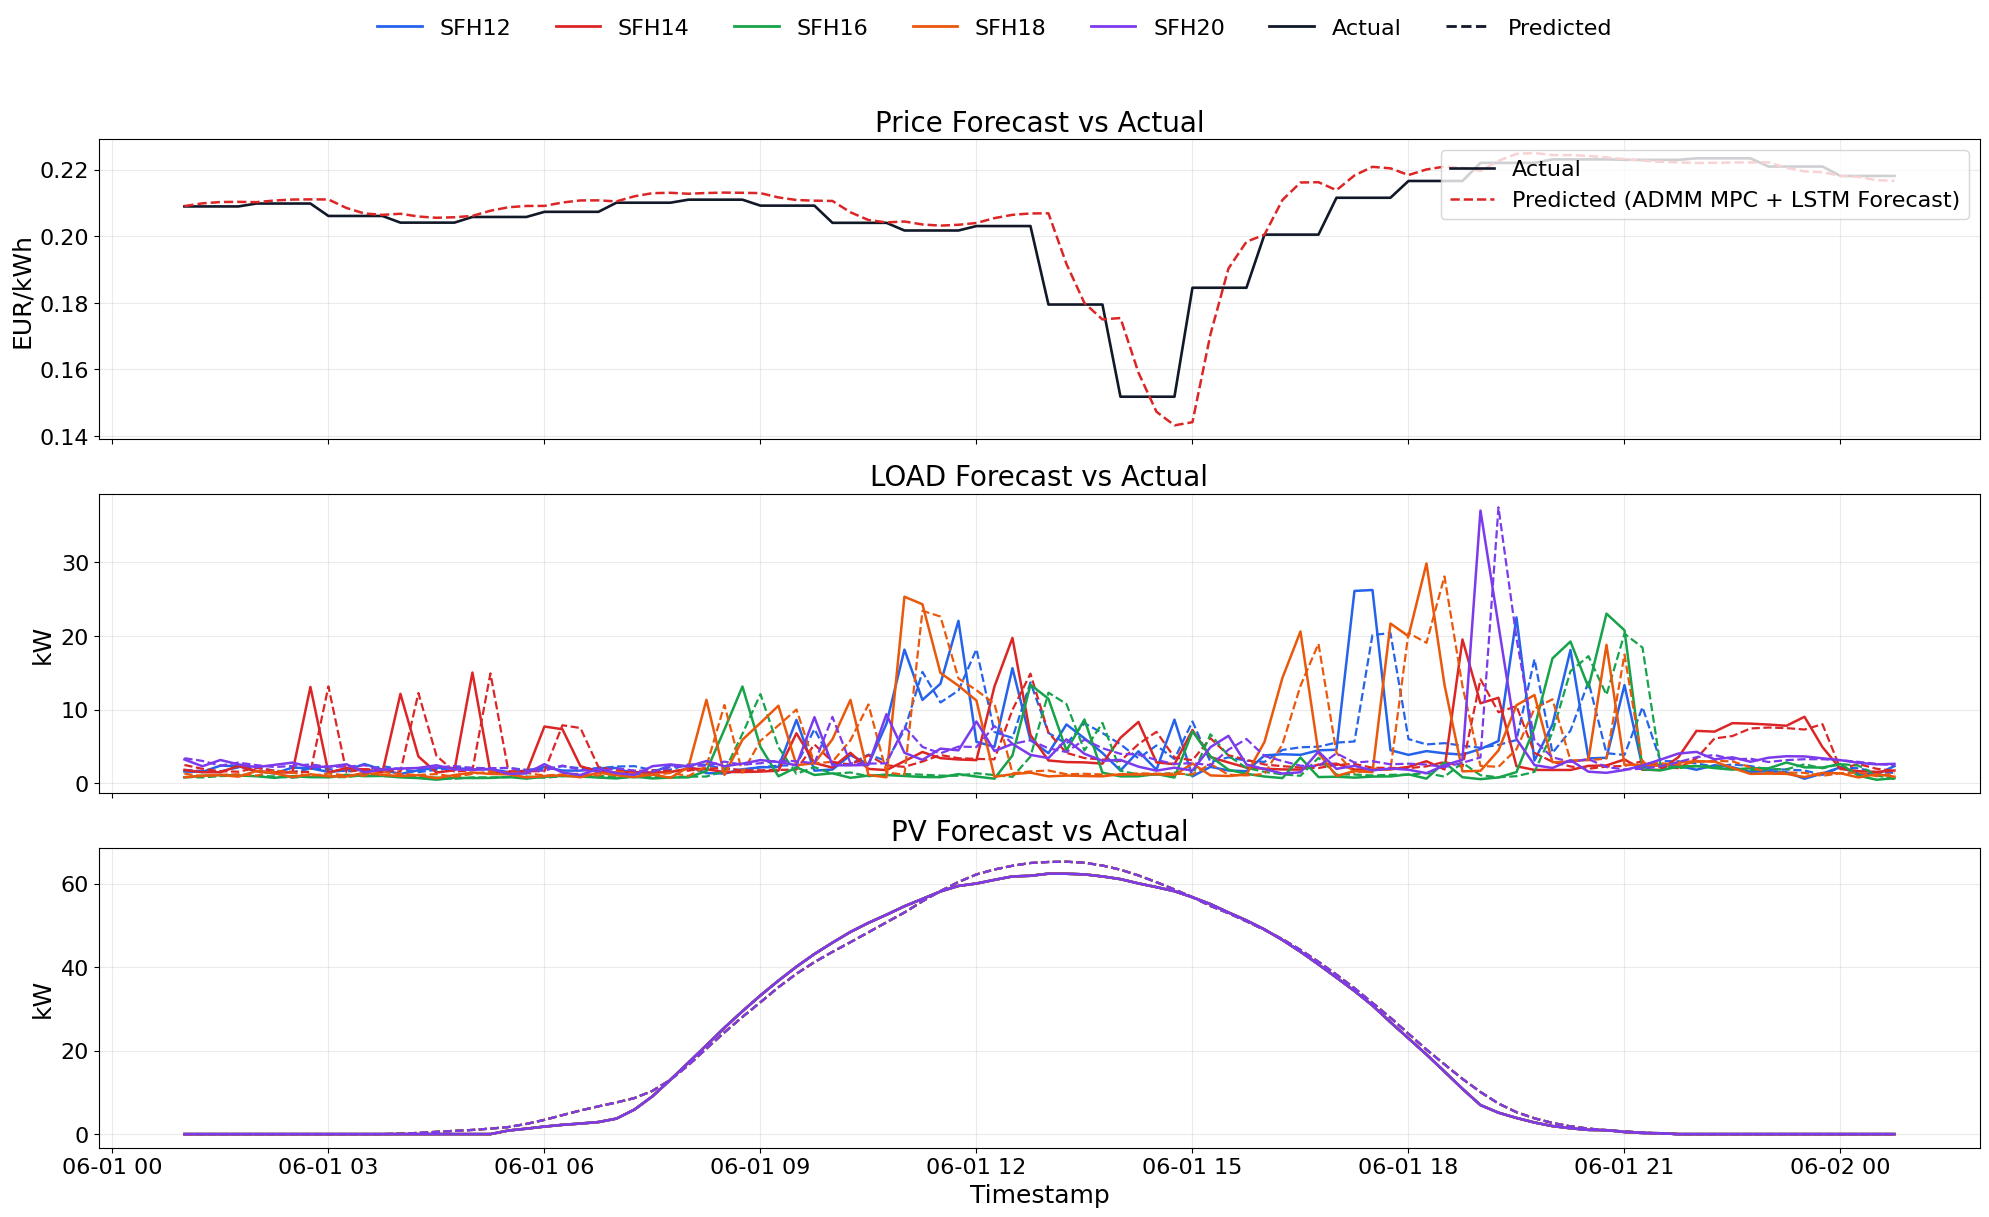

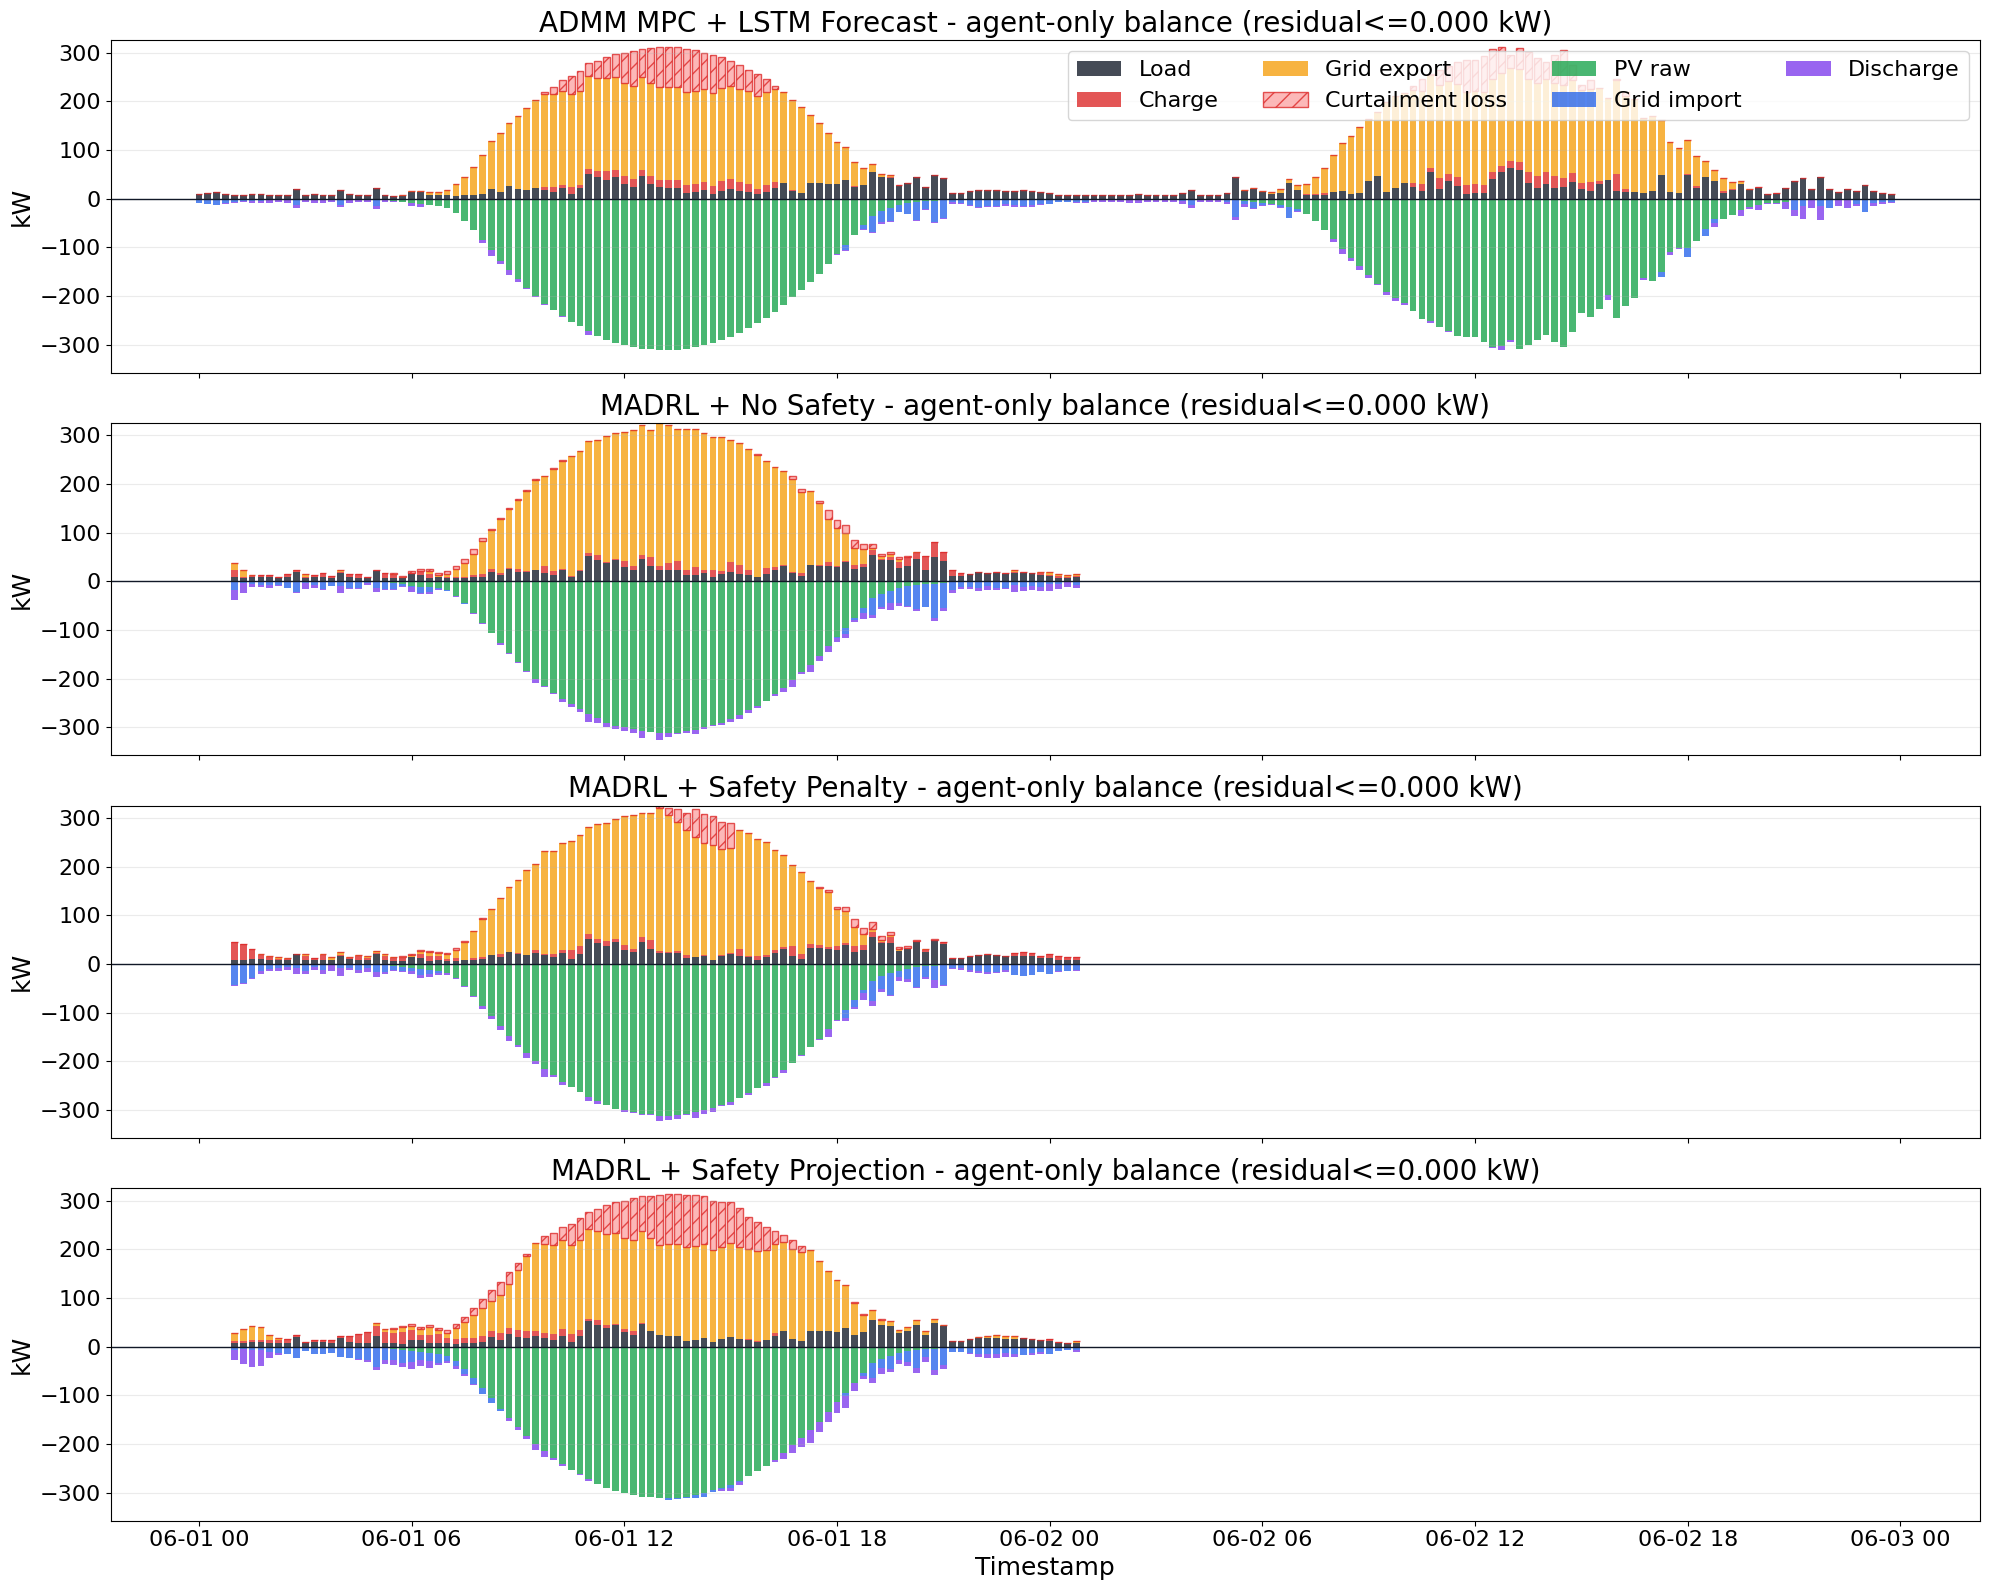

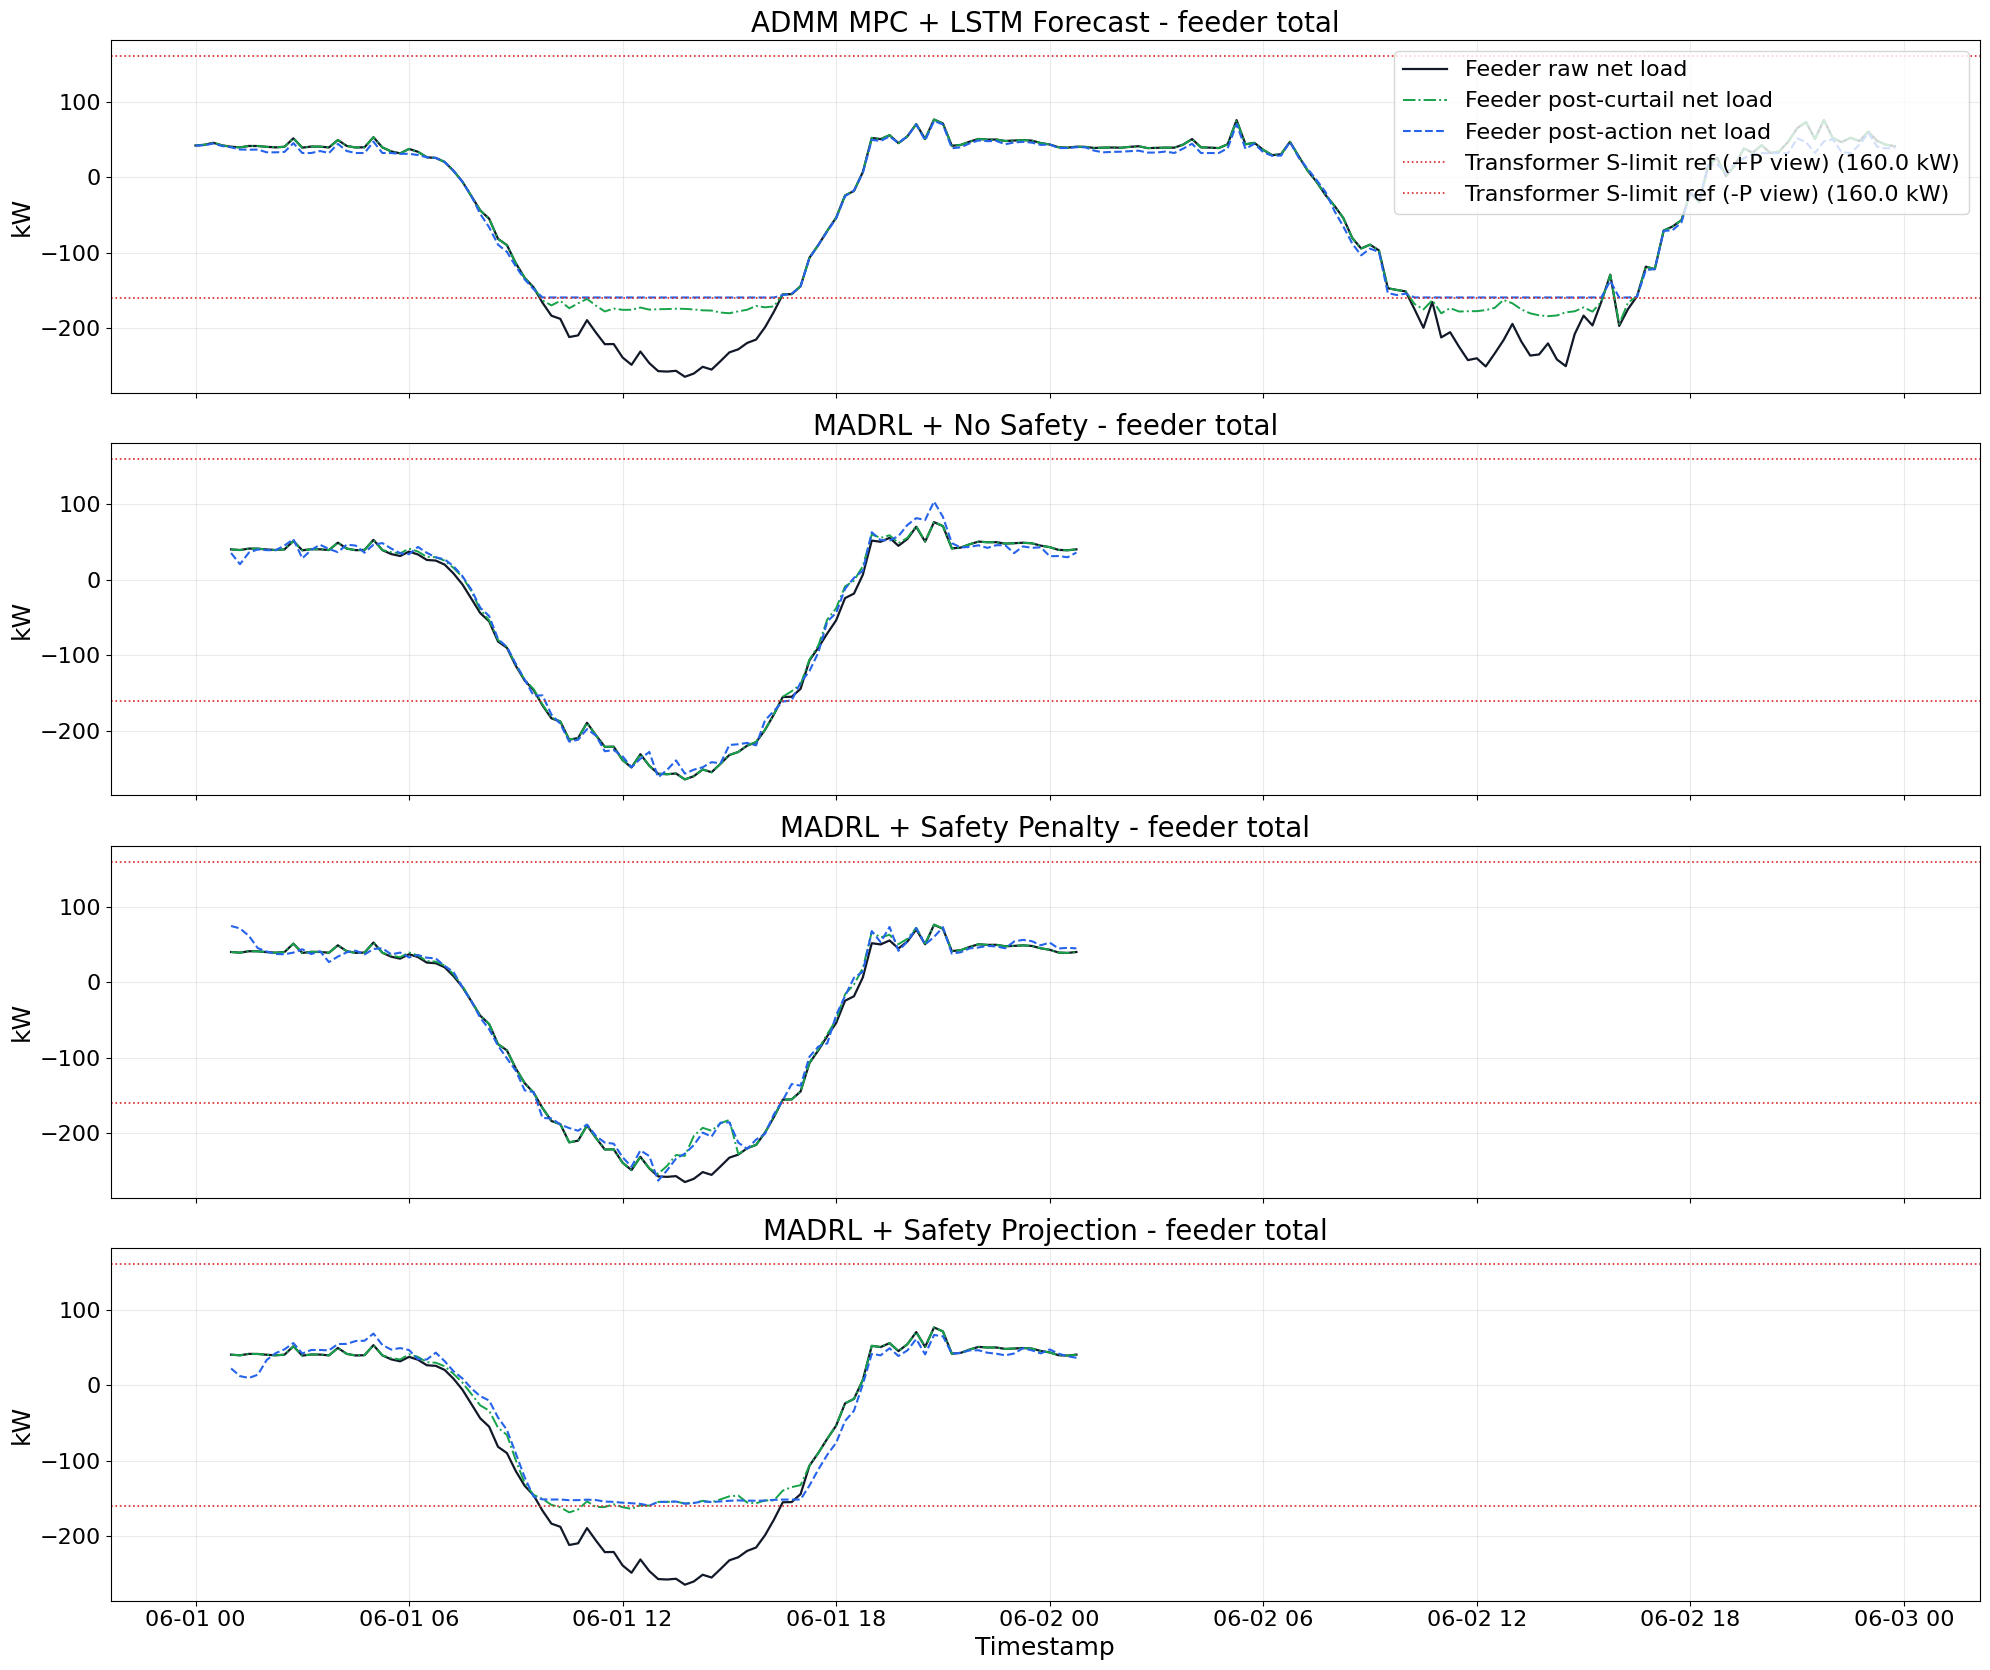

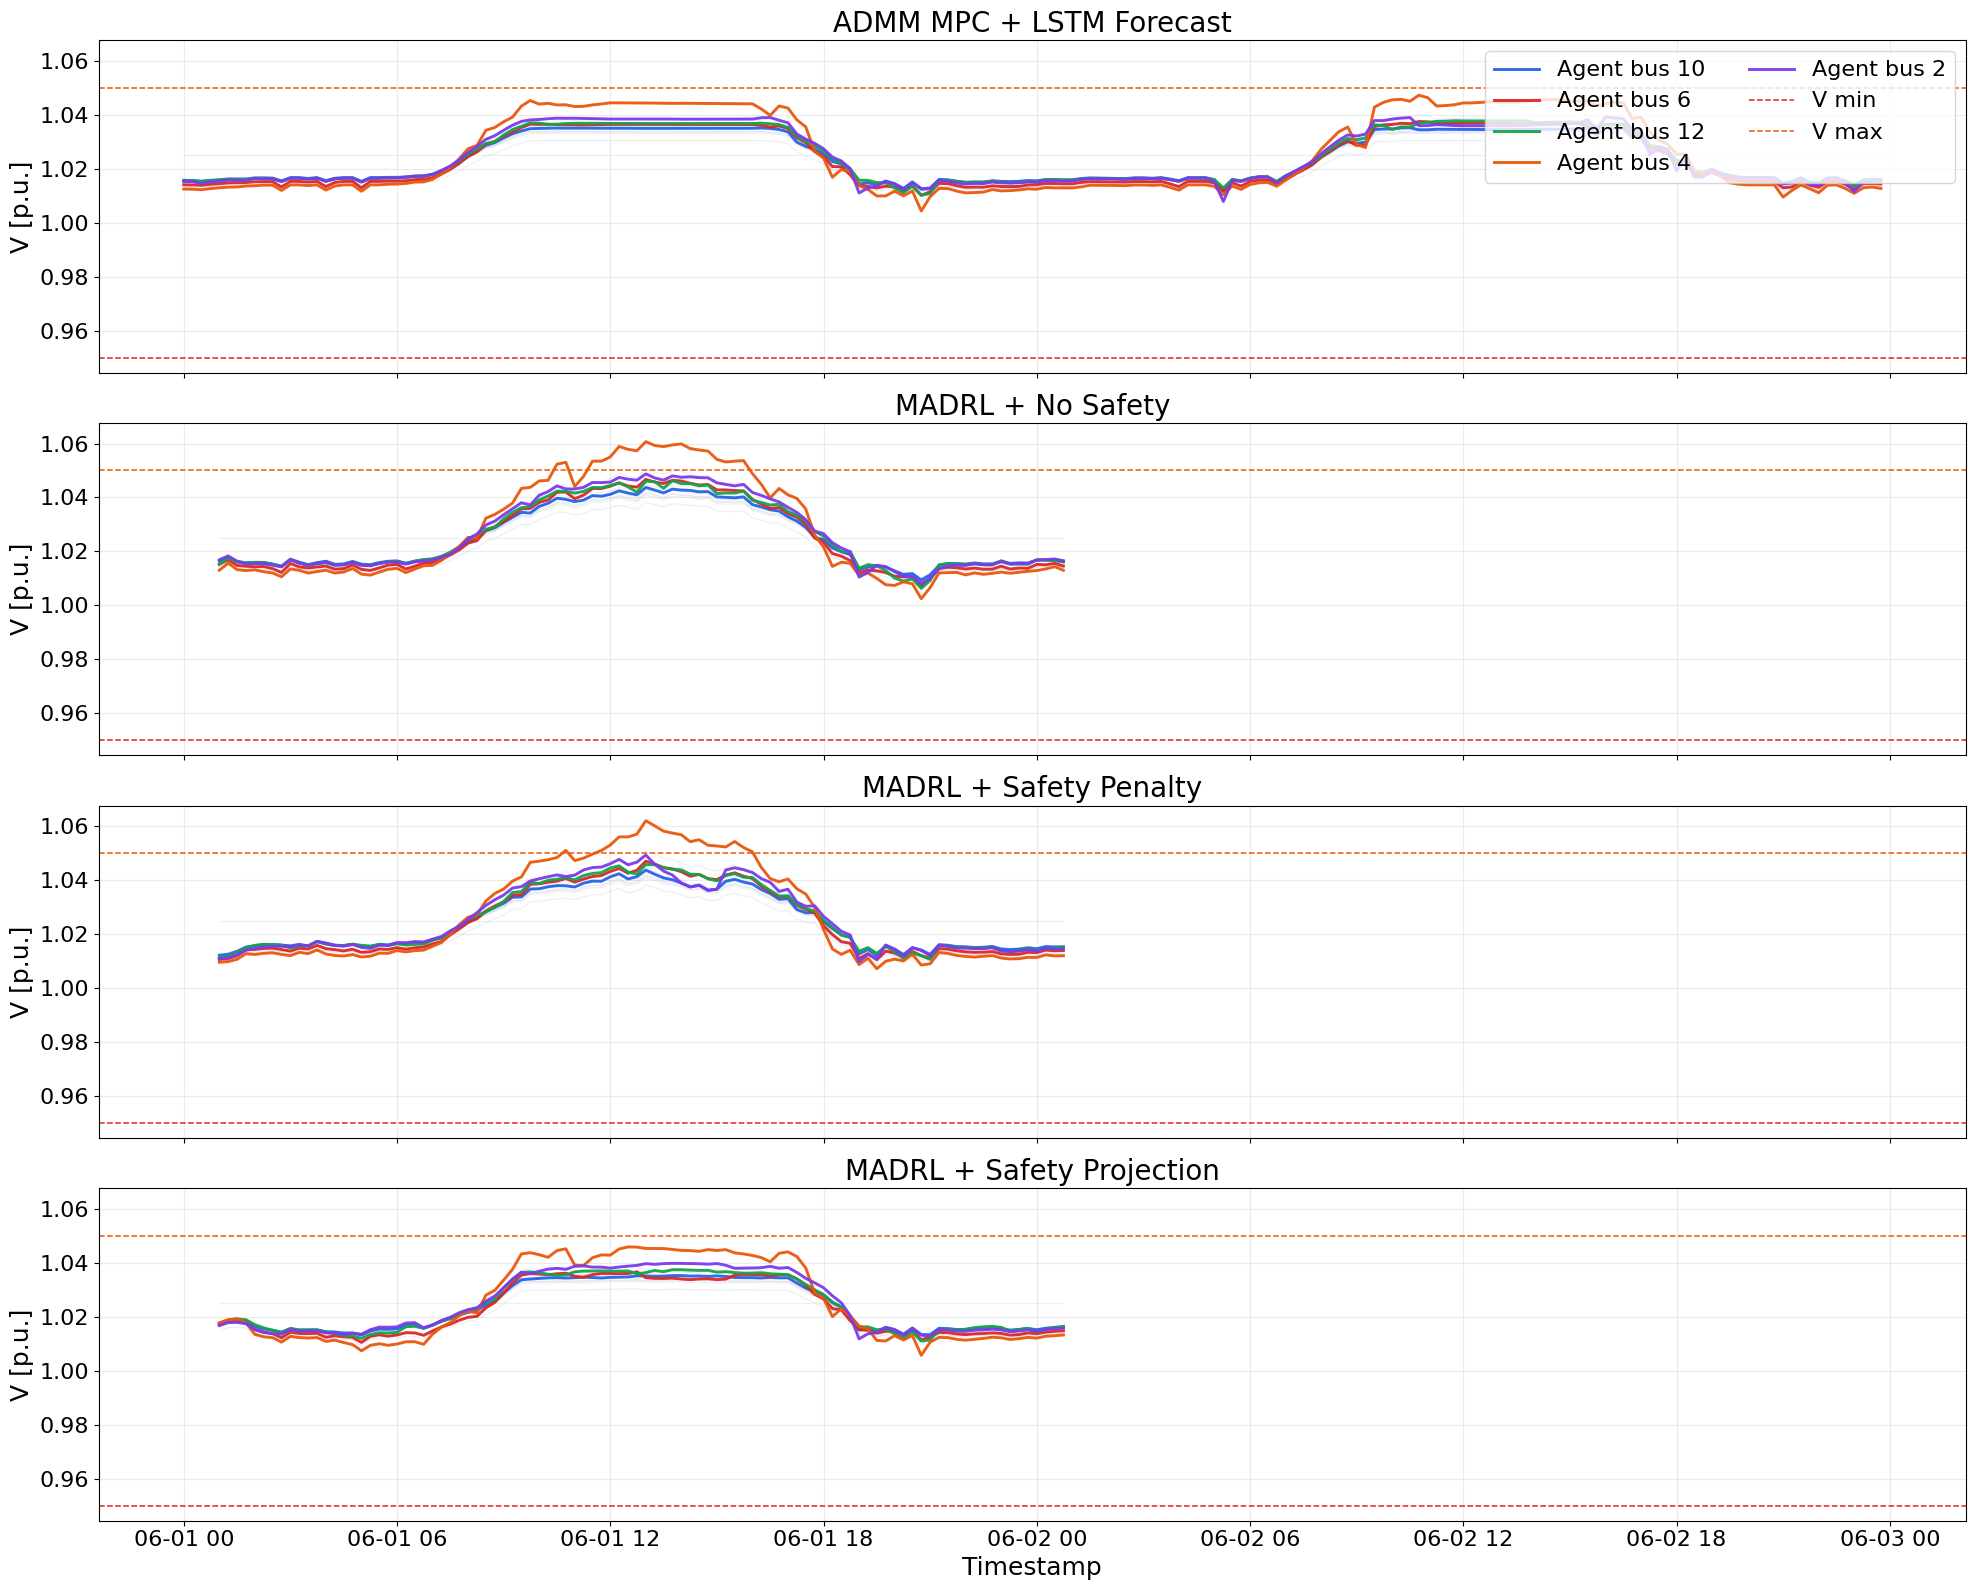

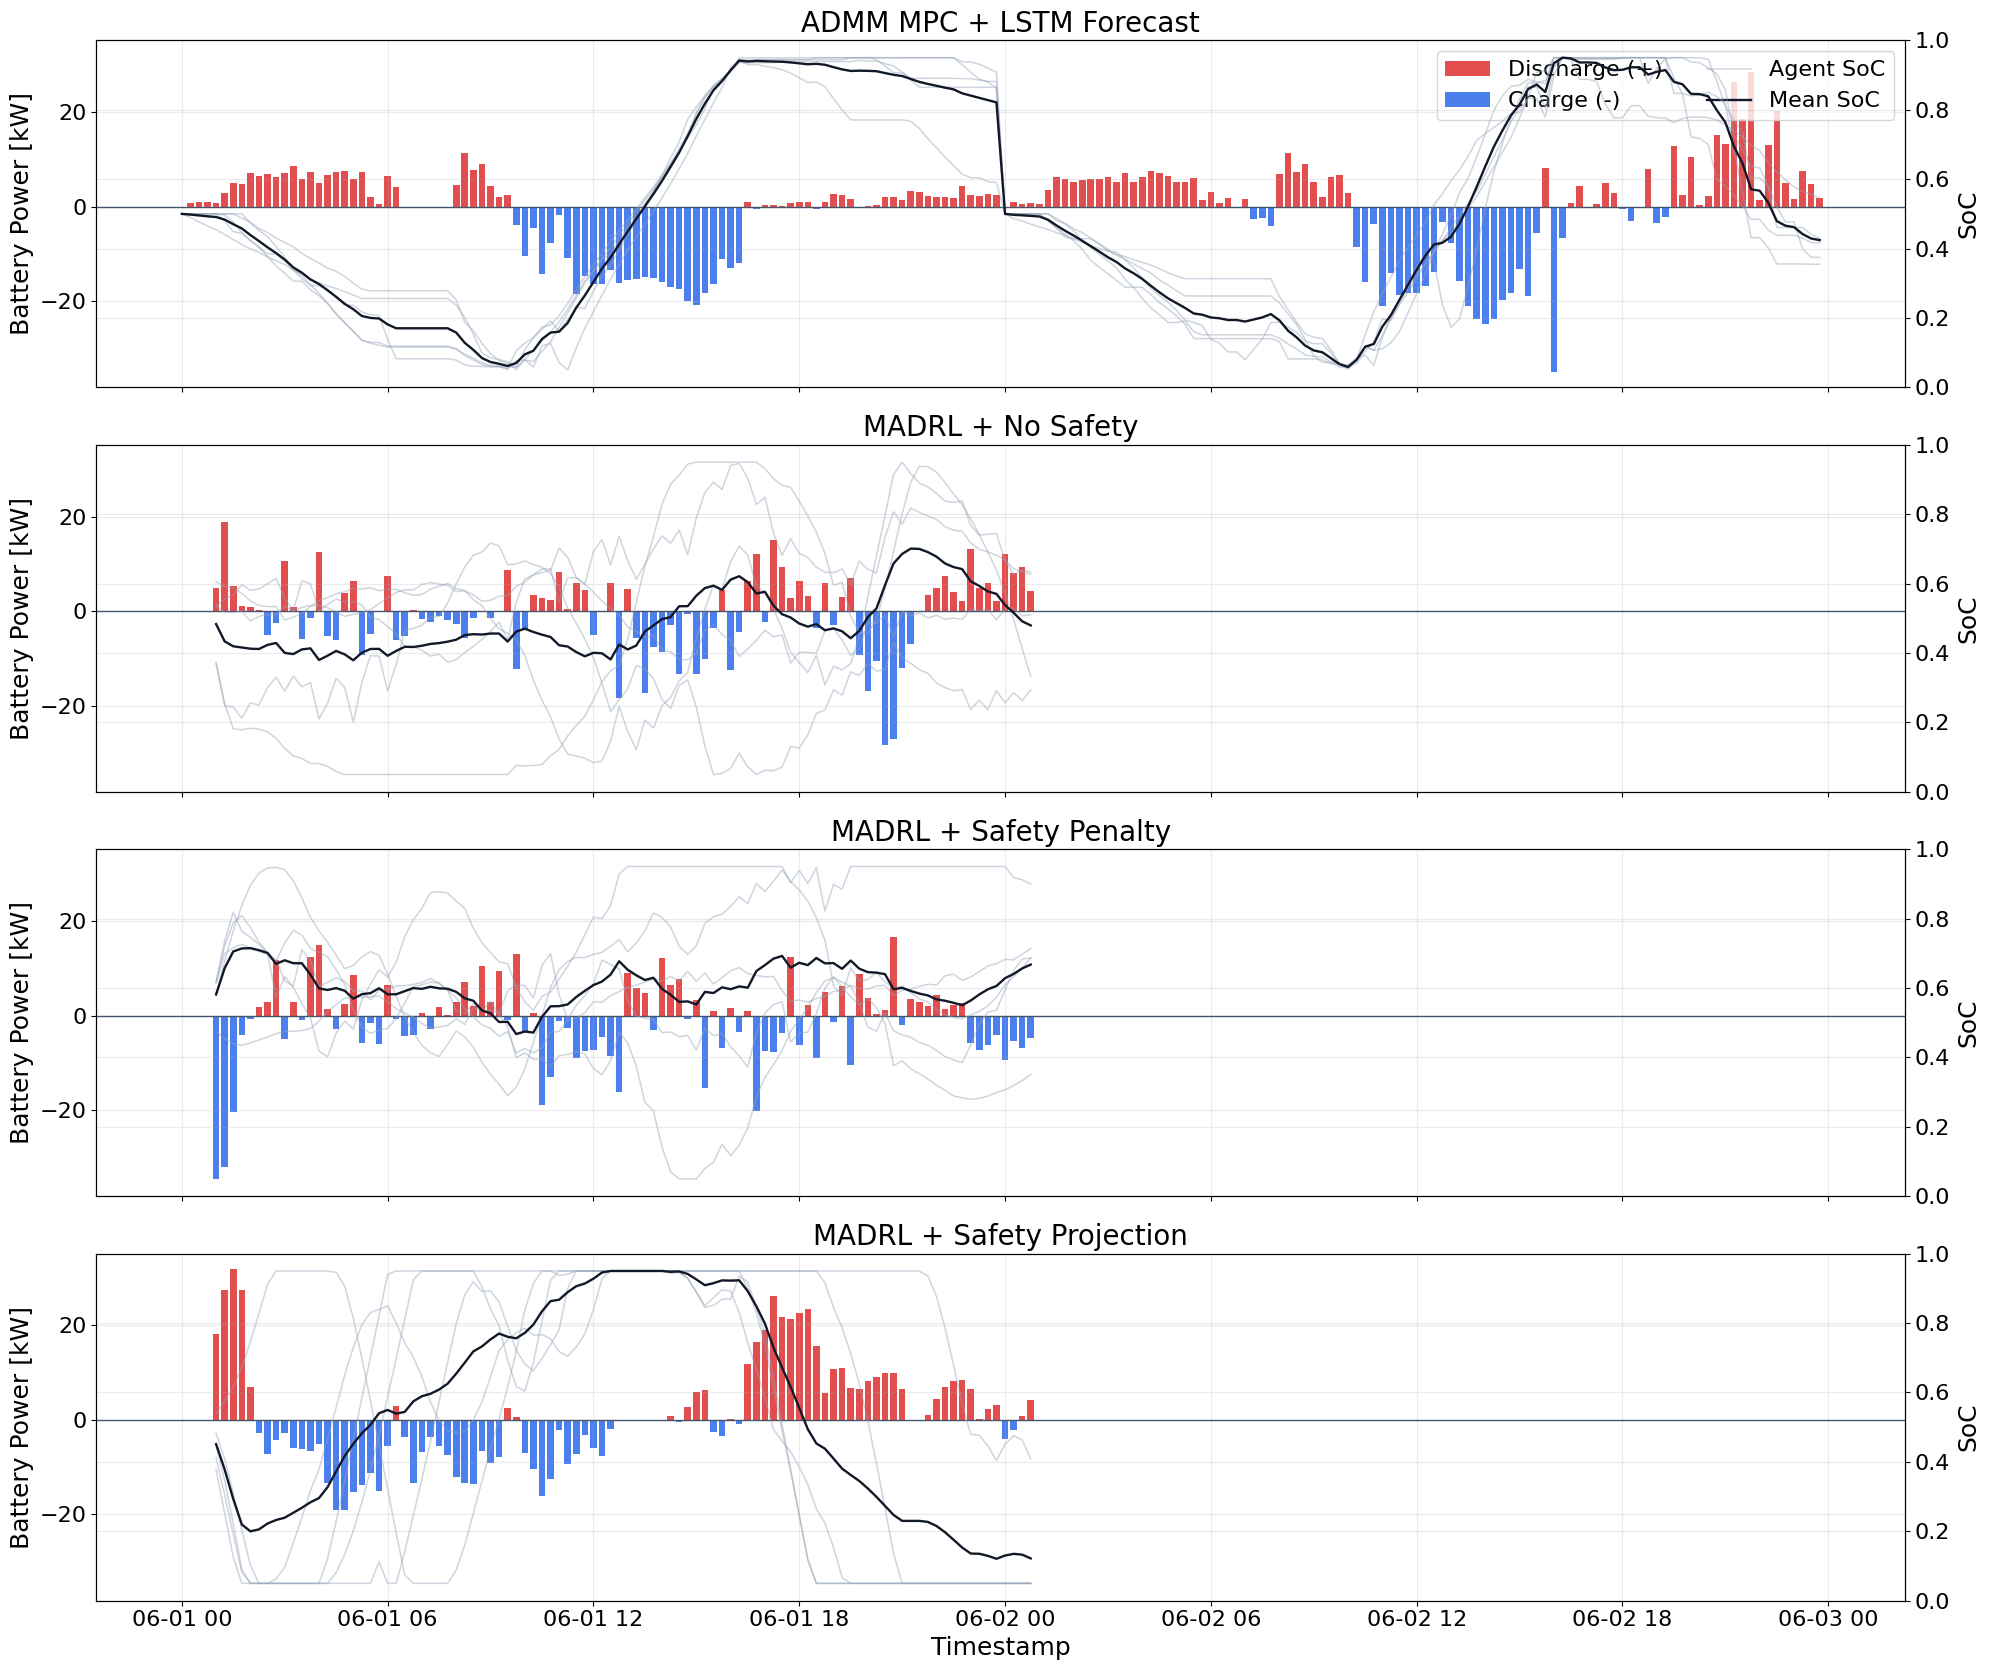

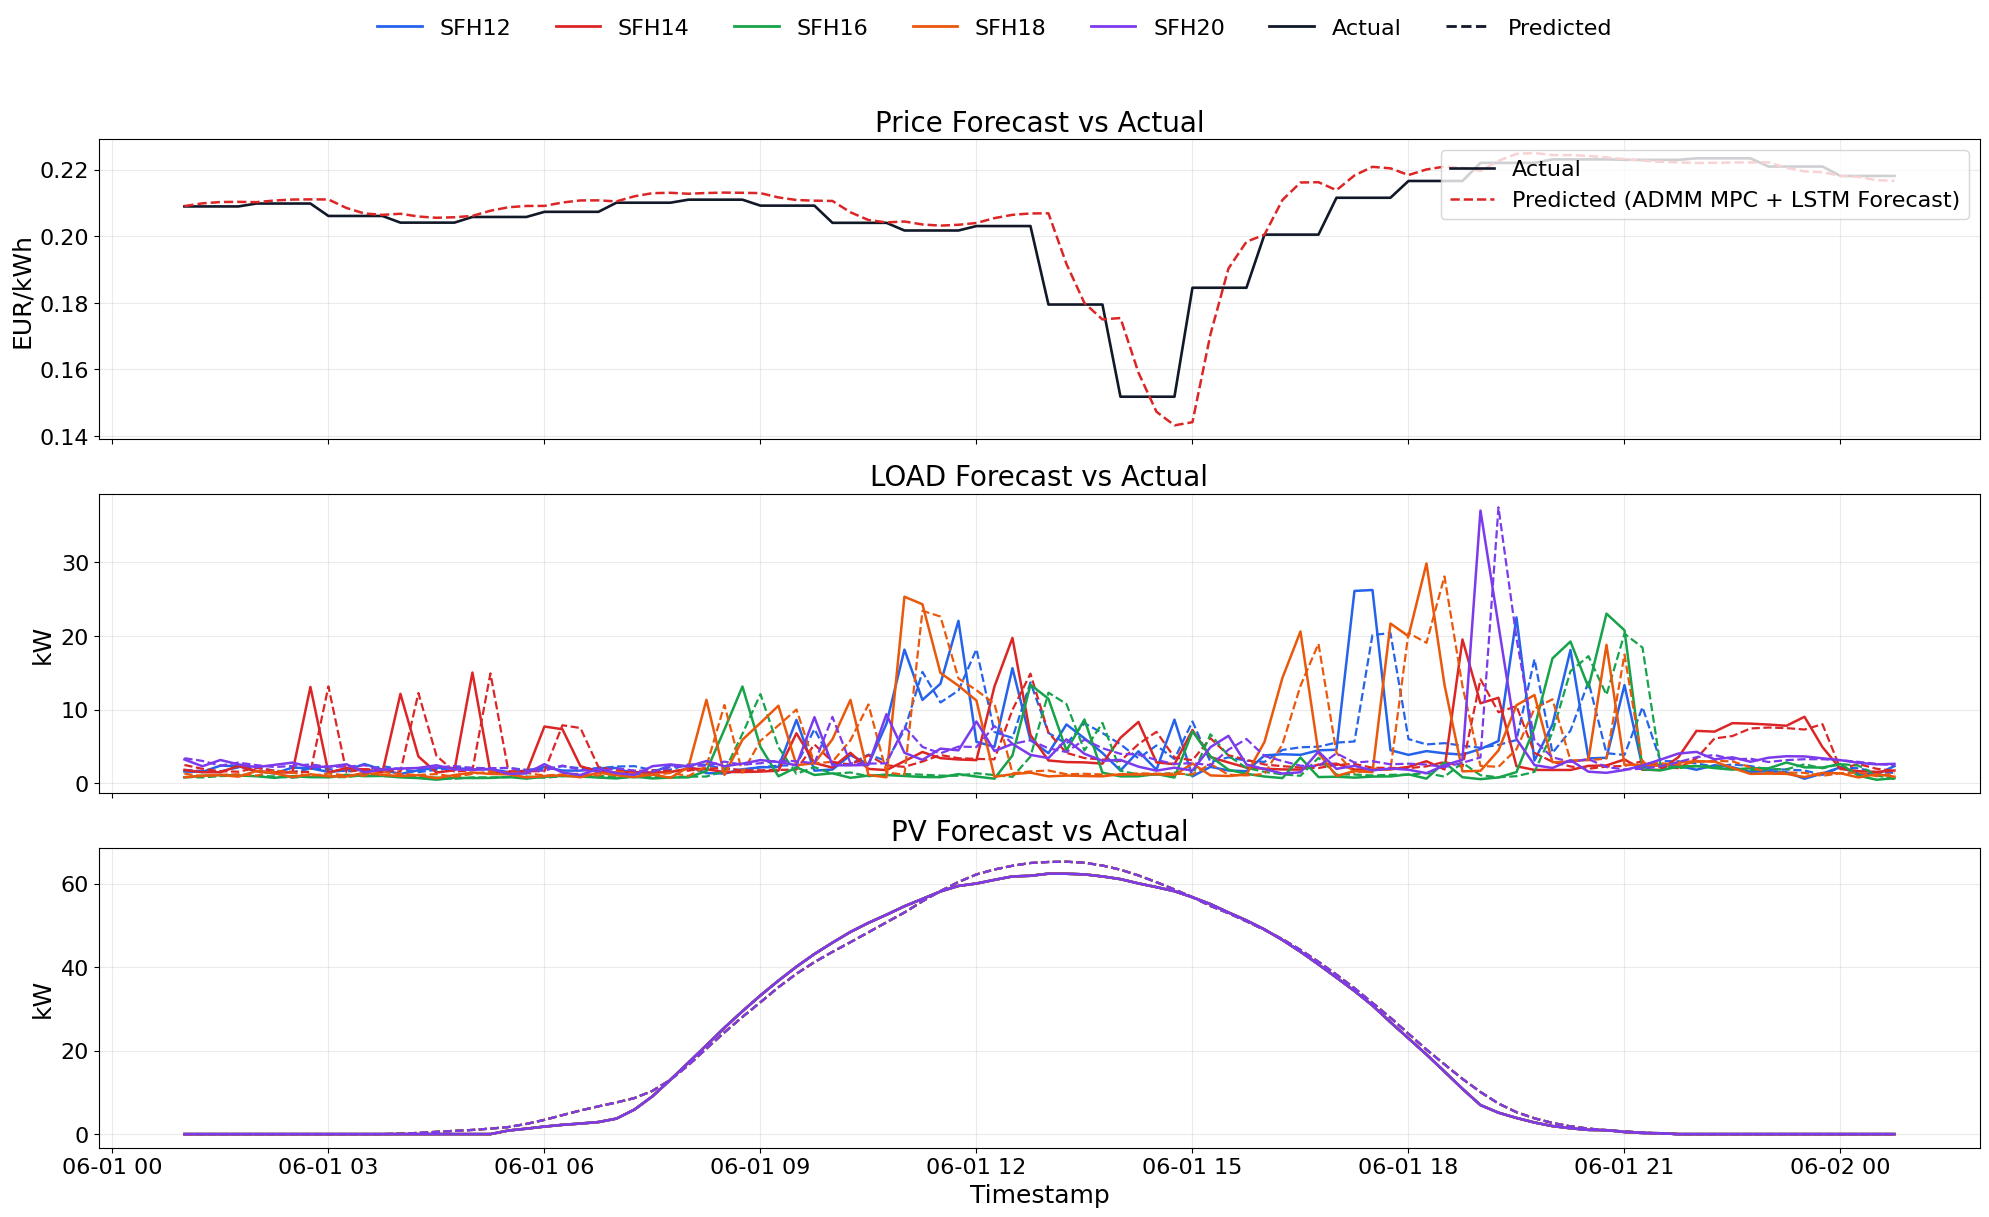

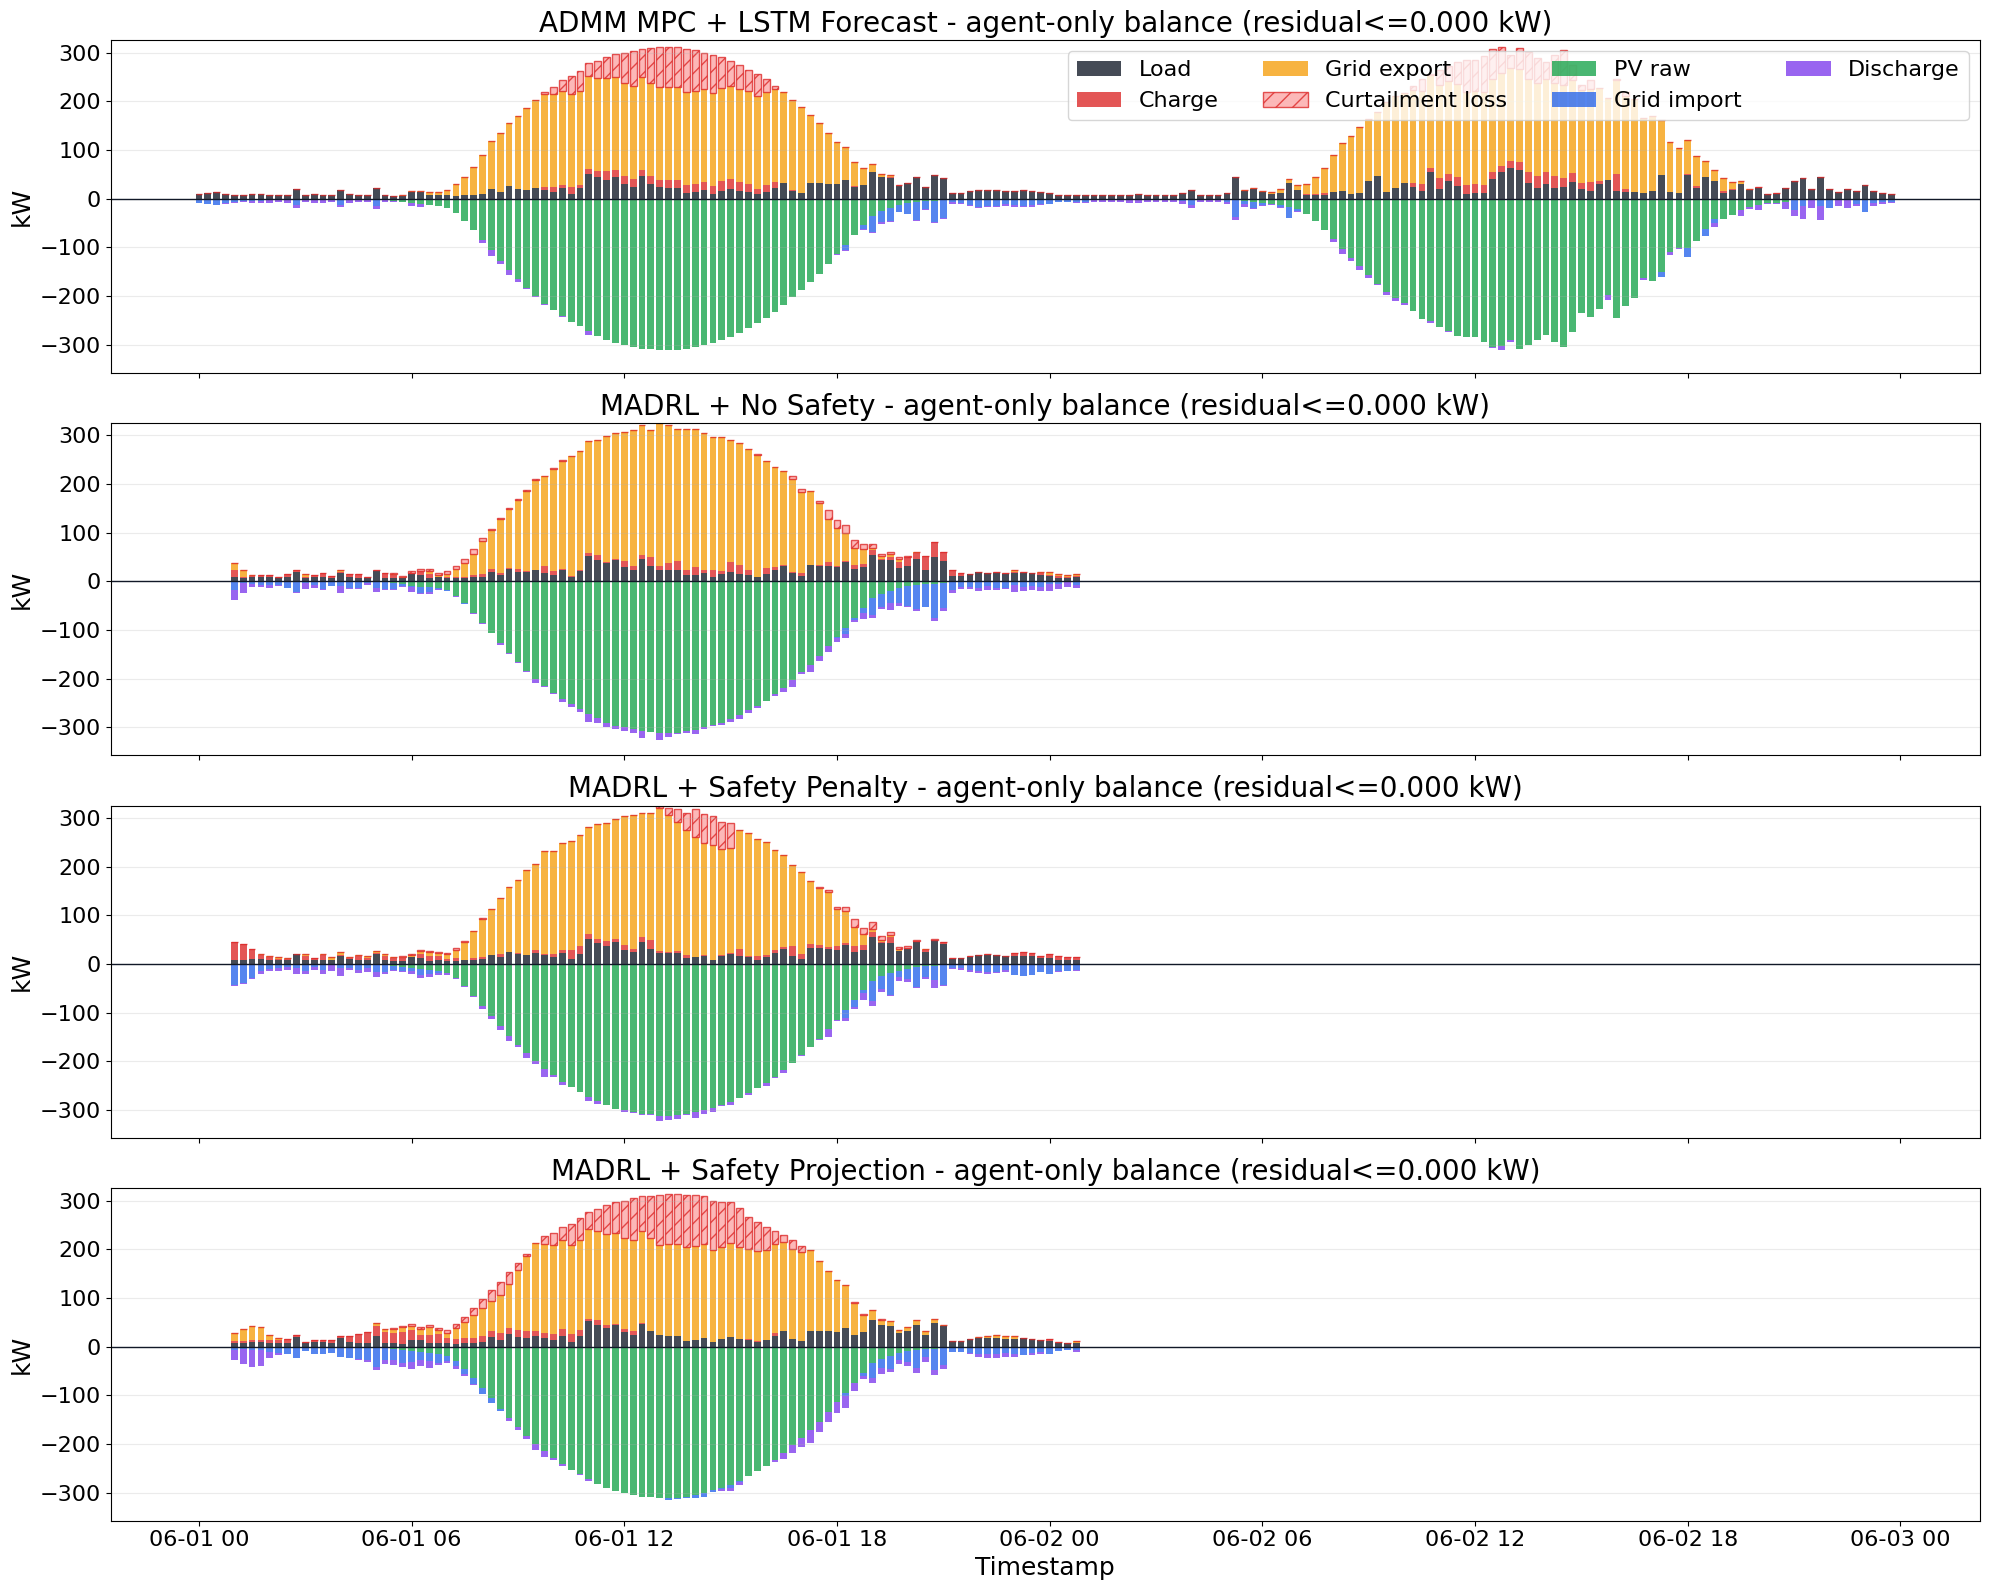

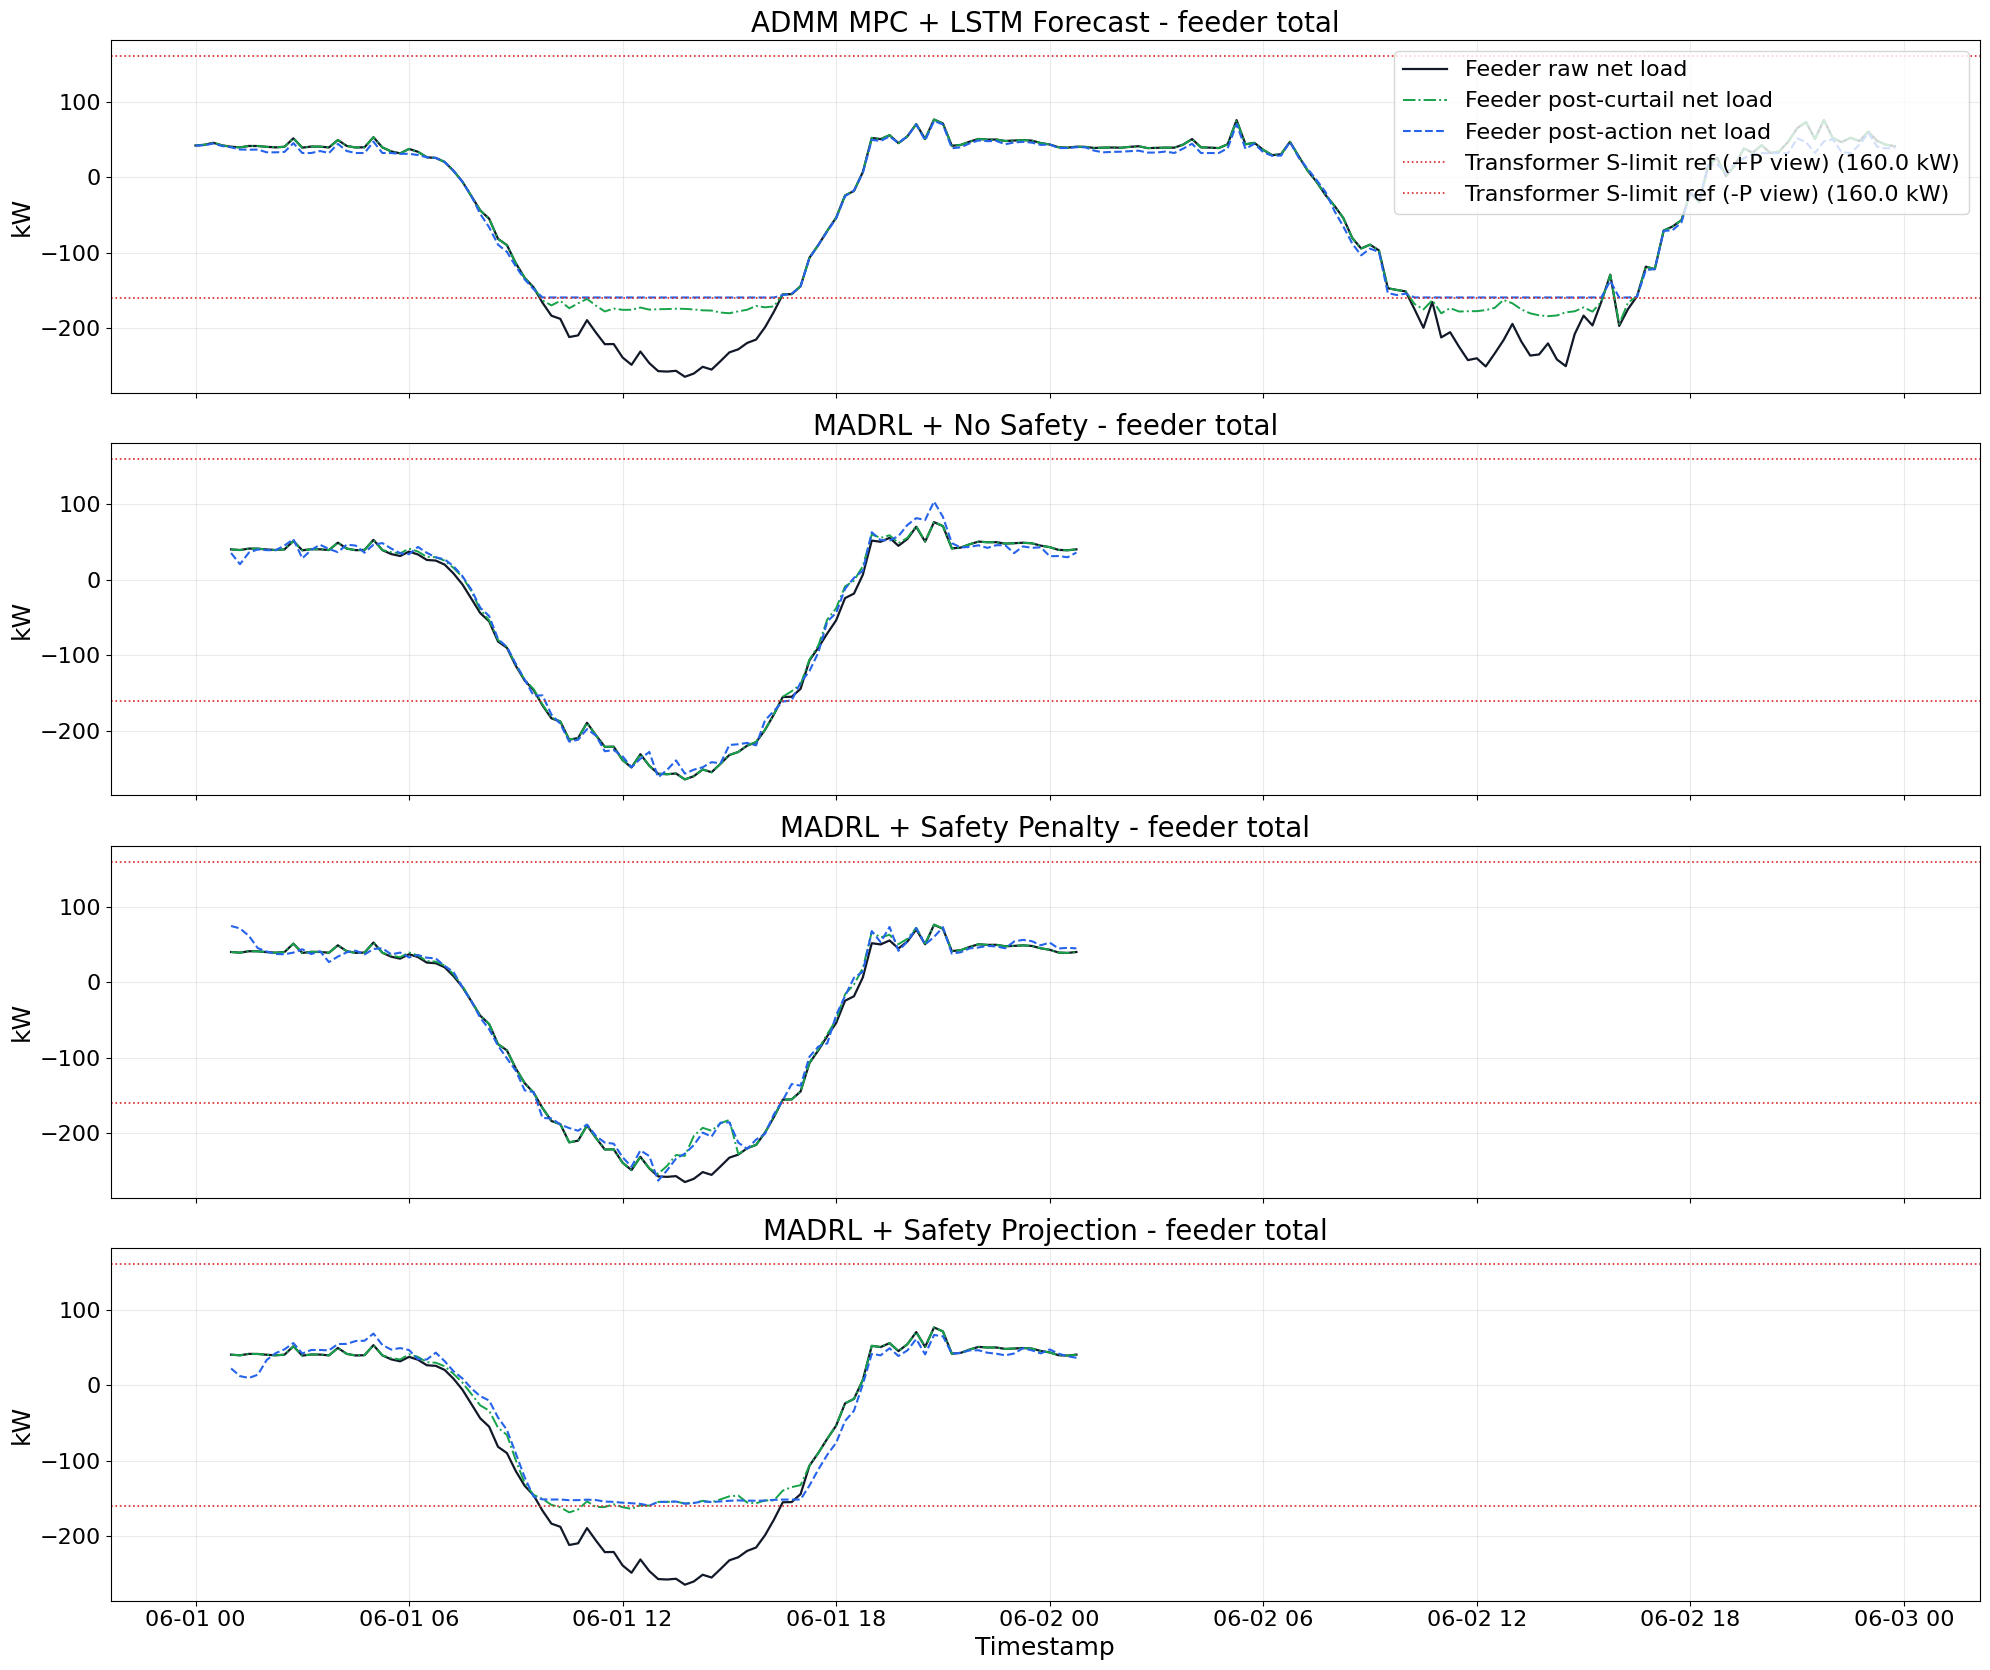

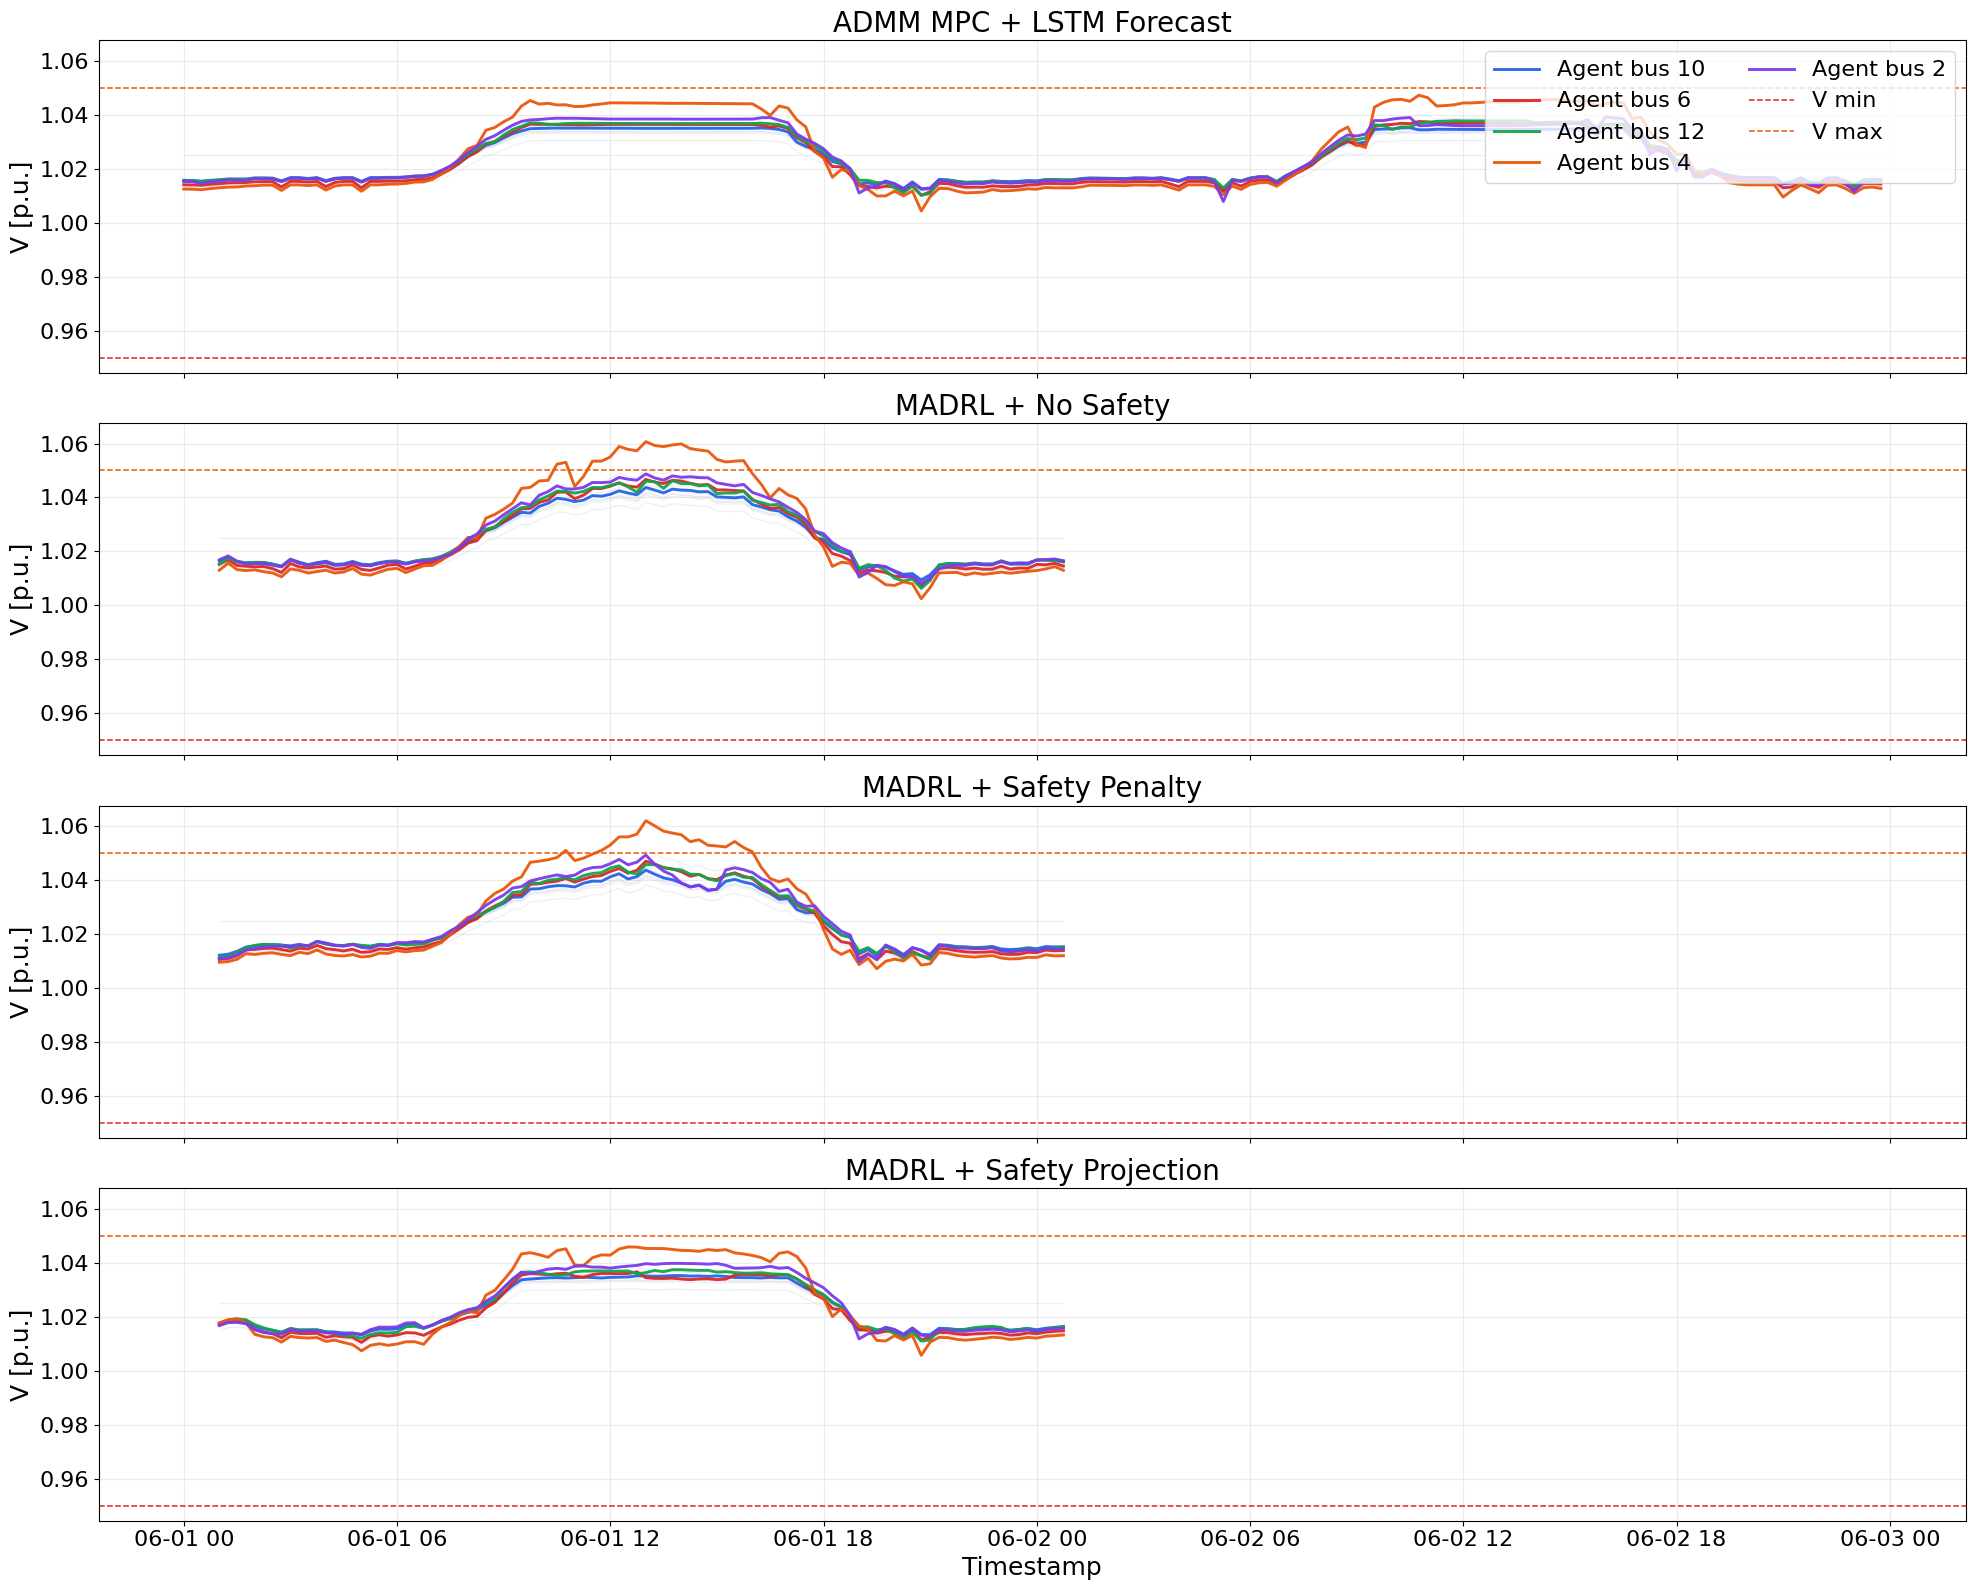

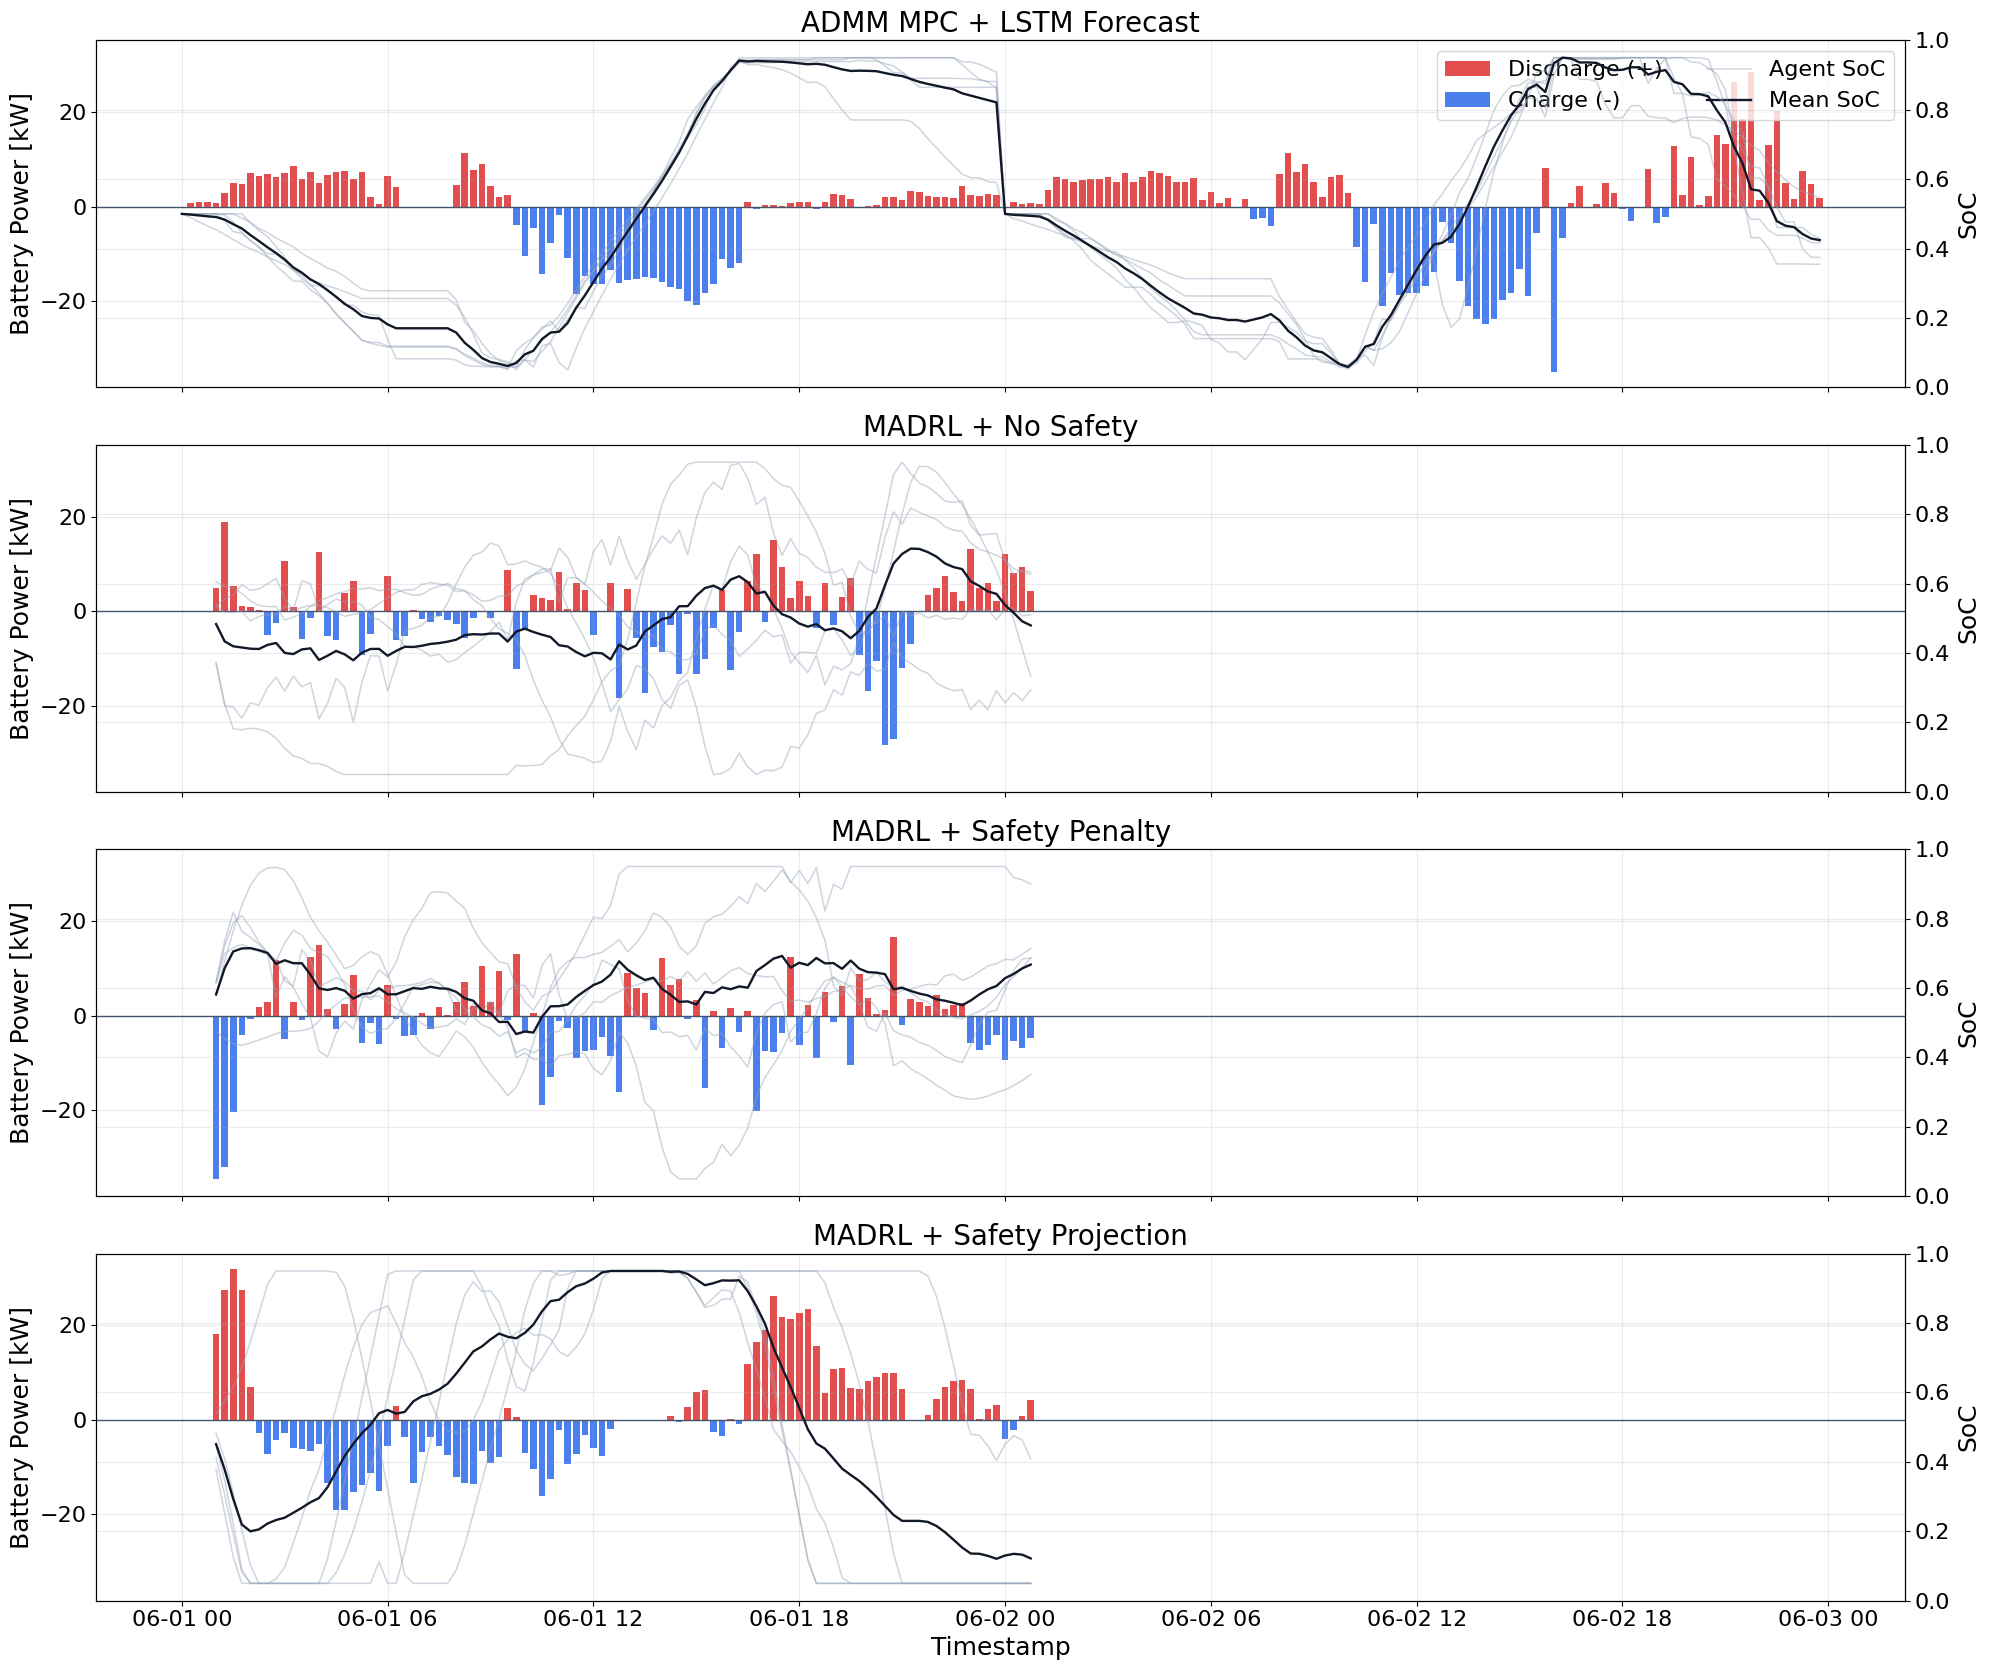

In [5]:
display(grid_nb.plot_shared_forecast_vs_actual(*rollouts))
display(grid_nb.plot_power_balance_comparison(*rollouts))

display(grid_nb.plot_net_load_comparison(*rollouts))
display(grid_nb.plot_voltage_profile_comparison(*rollouts))
display(grid_nb.plot_battery_power_and_soc_comparison(*rollouts))
